In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
from unittest.mock import patch
from sklearn.linear_model import LinearRegression
data_file = 'combined_ensemble_predictions_averaged_with_q.csv'
# Since the data has 3 classes, we want to collapse them into one q-value that maps the progression between healthy and full AD.
# [0, 0.5, 1] is equal weighting, where a patient uniformly progresses between CN and reaches AD.
# These values can be changed based on research and existing profiles of AD patients to be more realistic when modelling q.
constant_q_weighting = np.array([0, 0.5, 1])
constant_dx_to_q = {0: constant_q_weighting[0], 1: constant_q_weighting[1], 2: constant_q_weighting[2]}

def direct_q():
    dataframe = pd.read_csv('combined_ensemble_predictions_averaged.csv')
    dataframe['pred_q'] = (constant_q_weighting[0] * dataframe['CNPred']) + (constant_q_weighting[1] * dataframe['MCIPred']) + (constant_q_weighting[2] * dataframe['ADPred'])
    dataframe['true_q'] = dataframe['FollowupDX'].map(constant_dx_to_q)
    dataframe.to_csv(data_file, index=False)

In [2]:
df=pd.read_csv('combined_ensemble_predictions_averaged_with_q.csv')
df

,RID,delta_t,CNPred,MCIPred,ADPred,BaselineDX,FollowupDX,pred_q,true_q
0,4.0,12.1639,0.039251,0.622712,0.338037,1,1,0.649393,0.5
1,4.0,36.2623,0.015806,0.482246,0.501948,1,1,0.743071,0.5
2,5.0,11.9016,0.800081,0.199276,0.000642,0,0,0.100280,0.0
3,5.0,23.9344,0.759345,0.240200,0.000455,0,0,0.120555,0.0
4,5.0,36.0328,0.723376,0.276244,0.000380,0,0,0.138502,0.0
...,...,...,...,...,...,...,...,...,...
4708,7088.0,11.8361,0.002461,0.324007,0.673533,1,2,0.835536,1.0
4709,7088.0,24.0000,0.000748,0.259021,0.740231,1,2,0.869741,1.0
4710,7088.0,36.0000,0.000398,0.228977,0.770625,1,2,0.885114,1.0
4711,7088.0,48.0000,0.000228,0.212631,0.787141,1,2,0.893456,1.0


In [3]:
import sys
sys.path.append('/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/')
import optimalrcs,metrics,plots,nonparametrics,cut_profiles


In [4]:
i_traj=cp.asarray(df['RID'].to_numpy(),dtype=np.int32)
print(i_traj.shape)
print(i_traj)

r_traj=cp.asarray(df['pred_q'].to_numpy(),dtype=np.float32)
print(r_traj.shape)
print(r_traj)

(4713,)
[   4    4    5 ... 7088 7088 7088]
(4713,)
[0.6493932  0.7430712  0.10028047 ... 0.8851136  0.89345634 0.8985571 ]


# First we plot free energy profile along some Order Parameter (OP) - 
variable, that can be used to define the boundary states.

we consider first and second halves of the profiles to see the range of statistical fluctiations/uncertainity 

on the right panel we shifted curves of halfs of trajectories for better overlap

/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/plots.py:86: RuntimeWarning: divide by zero encountered in log
  ax.plot(lx[:-2].get(), -np.log(2 * lzh[:-2].get()), lt)
/tmp/ipykernel_2407117/3799135420.py:13: RuntimeWarning: divide by zero encountered in log
  ax2.plot(lx[:-2].get(), -np.log(2 * lzh[:-2].get()),'-r', label='full')
/tmp/ipykernel_2407117/3799135420.py:15: RuntimeWarning: divide by zero encountered in log
  ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'g:', label='1/2')
/tmp/ipykernel_2407117/3799135420.py:17: RuntimeWarning: divide by zero encountered in log
  ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'b:', label='2/2')


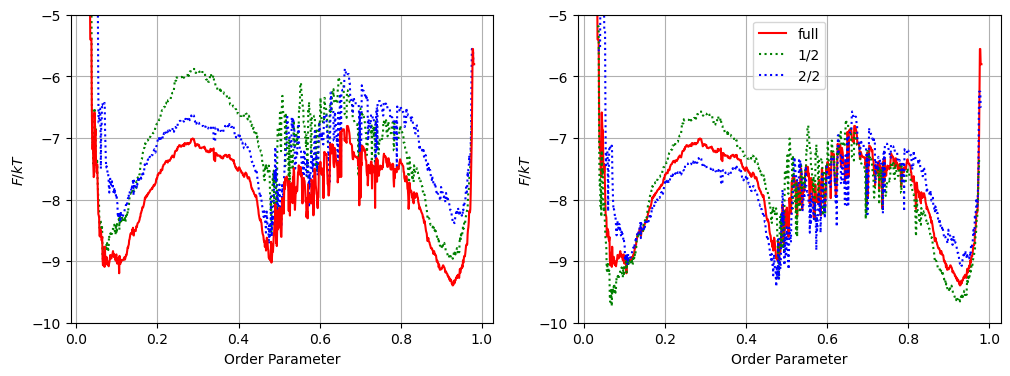

In [5]:
#OP=df['MCIPred'].to_numpy()/2+ df['ADPred'].to_numpy()
OP=r_traj

fig, (ax1,ax2)=plt.subplots(1,2,figsize=(12,4))

nn=len(OP)//2
plots.plot_fep(ax1,OP[:nn],lt='g:', i_traj=cp.asarray(i_traj[:nn]))
plots.plot_fep(ax1,OP[nn:],lt='b:', i_traj=cp.asarray(i_traj[nn:]))
plots.plot_fep(ax1,OP,xlabel='Order Parameter',lt='r-', i_traj=cp.asarray(i_traj))
ax1.set(ylim=(-10,-5))

lx, lzh = cut_profiles.comp_zca(cp.asarray(OP), a=-1,i_traj=cp.asarray(i_traj))
ax2.plot(lx[:-2].get(), -np.log(2 * lzh[:-2].get()),'-r', label='full')
lx, lzh = cut_profiles.comp_zca(cp.asarray(OP[:nn]), a=-1,i_traj=cp.asarray(i_traj[:nn]))
ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'g:', label='1/2')
lx, lzh = cut_profiles.comp_zca(cp.asarray(OP[nn:]), a=-1,i_traj=cp.asarray(i_traj[nn:]))
ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'b:', label='2/2')
    
ax2.set(ylabel='$F/kT$', xlabel='Order Parameter')
ax2.grid()
ax2.set(ylim=(-10,-5))
_=ax2.legend()


In [6]:
import re

lat_df = pd.read_csv('latent_representations_per_visit.csv')

def parse_latent_string(s: str) -> np.ndarray:
    cleaned = re.sub(r'\s+', ' ', s.strip().strip('[]'))
    return np.fromstring(cleaned, sep=' ')

lat_df['latent_vec'] = lat_df['latent'].apply(parse_latent_string)
df['latent_vec'] = lat_df['latent_vec'].values

z_traj = np.vstack(df['latent_vec'].values)

z_mean = z_traj.mean(axis=0)
z_std  = z_traj.std(axis=0)
z_std[z_std == 0] = 1.0
z_traj = (z_traj - z_mean) / z_std

print(f"z_traj shape: {z_traj.shape}")

z_traj shape: (4713, 32)


In [7]:
z_traj

array([[-0.06218813, -0.69426885, -0.63596854, ..., -0.21198935,
        -0.51346582, -0.89130044],
       [ 0.38380648, -0.80851309, -0.63596854, ...,  0.26556017,
        -0.2333904 , -0.91211003],
       [-0.79987639,  1.42843775,  1.51604249, ..., -1.01141819,
         0.41239149,  1.35753076],
       ...,
       [ 0.93657132, -0.90756277, -0.63596854, ...,  0.95584917,
         0.32336022, -0.9400388 ],
       [ 1.05279809, -0.90756277, -0.63596854, ...,  1.12104561,
         0.42084523, -0.93460546],
       [ 1.14859991, -0.90756277, -0.63596854, ...,  1.26942671,
         0.48212454, -0.93025451]], shape=(4713, 32))

In [8]:
import torch
from dataset import ADNI_tabular
from models.nmm import NMM
from utils.directory_navigator import DirectoryNavigator
N_RT = 20
N_RV = 3
N_RI = 3
root = './'
model_width = 128
model_depth = 3
num_classes = 3
dropout_rate = 0
model_name = 'NMM'
is_multi = True
fixed_followup_year = 0
num_of_tabular_features = 114
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root_splits = root + 'splits/'
raw_patient_inputs = {}
from utils.directory_navigator import DirectoryNavigator
dir_navi = DirectoryNavigator(root_splits, model_name, is_multi, fixed_followup_year)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='numpy')

def get_baseline_loader(i_rt, i_rv, dir_navi):
    dataset = ADNI_tabular(
        trainvaltest='Test',
        is_multi=is_multi,
        fixed_followup_year=fixed_followup_year,
        data_dir=dir_navi.get_data_dir(i_rt, i_rv=i_rv)
    )
    return torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

raw_patient_features = {}  # stores (114,) features array per RID, patient-level

for i_rt in range(N_RT):
    for i_rv in range(N_RV):
        loader = get_baseline_loader(i_rt, i_rv, dir_navi)
        batch = next(iter(loader))
        rids = [r.item() if hasattr(r, 'item') else r for r in batch['RID']]
        
        raw_input = torch.cat([
            batch['Features'],
            batch['delta_t'].unsqueeze(-1)
        ], dim=1).numpy()


        for idx, rid in enumerate(rids):
            if rid not in raw_patient_features:
                raw_patient_features[rid] = raw_input[idx].copy()

# Merge static features onto the visit-level df, then append each visit's actual delta_t.
# This gives one 115-dim row per visit: 114 clinical features + the real delta_t for that visit.
feat_df = pd.DataFrame({
    'RID': list(raw_patient_features.keys()),
    'features': list(raw_patient_features.values())
})
df_with_raw = df.merge(feat_df, on='RID', how='inner')

F = np.vstack(df_with_raw['features'].values)
delta_t_col = df_with_raw['delta_t'].values.reshape(-1, 1)
X_raw = np.hstack([F, delta_t_col])

X_raw

array([[-8.72343659e-01, -2.19731951e+00, -3.65367606e-02, ...,
         1.00000000e+00,  1.21639000e+01,  1.21639000e+01],
       [-8.72343659e-01, -2.19731951e+00, -3.65367606e-02, ...,
         1.00000000e+00,  1.21639000e+01,  3.62623000e+01],
       [-1.48661761e-02, -3.11584529e-02, -9.85048354e-01, ...,
         1.00000000e+00,  1.19016000e+01,  1.19016000e+01],
       ...,
       [-5.20587742e-01, -2.18316223e-02,  4.66481209e-01, ...,
         1.00000000e+00,  1.18361000e+01,  3.60000000e+01],
       [-5.20587742e-01, -2.18316223e-02,  4.66481209e-01, ...,
         1.00000000e+00,  1.18361000e+01,  4.80000000e+01],
       [-5.20587742e-01, -2.18316223e-02,  4.66481209e-01, ...,
         1.00000000e+00,  1.18361000e+01,  6.00000000e+01]],
      shape=(4713, 65))

In [9]:
df_with_raw['features'][0]

array([-8.72343659e-01, -2.19731951e+00, -3.65367606e-02, -6.24240160e-01,
        0.00000000e+00,  4.99637948e-16,  6.07844554e-16,  1.21457399e-15,
       -5.13621297e-16, -4.06403391e-16,  1.19124236e-15,  0.00000000e+00,
        4.61885001e-16,  5.61126664e-16,  0.00000000e+00,  0.00000000e+00,
       -3.75613743e-16,  5.01164778e-16,  1.08434153e+00,  8.98139775e-01,
        4.08278465e-01, -5.31974614e-01,  2.58193887e-03,  9.16147530e-01,
       -1.01547875e-01, -4.89210635e-01, -7.76520550e-01, -1.91463399e+00,
        2.55426812e+00,  0.00000000e+00, -7.93946862e-01, -1.11093986e+00,
        1.32560313e+00, -1.31776953e+00, -1.26563811e+00,  0.00000000e+00,
        2.44513560e-14,  0.00000000e+00,  5.53597771e-02, -8.66953880e-02,
        1.15528297e+00,  4.80828434e-01,  5.63380659e-01, -6.75845146e-02,
        8.85078013e-01,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  

In [10]:
def plot_filtered(q, lag_times):
    q.plots_feps(ldt=lag_times)
    q.plots_obs_pred()

In [11]:
ad_mask = df['FollowupDX'] == 2
median_observed = df.loc[ad_mask, 'delta_t'].median()
raw = -np.log(np.clip(df['pred_q'].to_numpy(), 1e-3, 1.0))
T_scale = median_observed / np.median(raw[ad_mask])

seed_r = T_scale * raw
seed_r

array([ 218.61240567,  150.37605573, 1164.56258147, ...,   61.79812175,
         57.04756225,   54.16483063], shape=(4713,))

## Interpretation
```text
q ≈ probability that this patient trajectory reaches AD before returning to / remaining in a healthy reference state
```

## Boundaries
```python
boundary1 = first visit where FollowupDX == 2
```
```python
boundary0 = final visit of patients who remain CN for their whole observed trajectory
```

This is the stable healthy/non-progressor boundary, state `A`.

Patients who are MCI, mixed, unstable, or censored without stable CN are left as interior trajectory data. Their points can occupy:
```text
0 < q < 1
```

## What `plots_obs_pred()` Measures
```text
Among trajectory segments with predicted q ≈ x,
what fraction actually reach boundary B before boundary A?
```

Ideal result:

```text
observed pB ≈ predicted pB
```

## What Zq Measures
Interpretation:

- Flat Zq: locally committor-like dynamics.
- Sloped or curved Zq: systematic drift; the coordinate is not dynamically optimal.
- Different lag curves disagreeing: inconsistency across timescales.
- Negative Zq values: not necessarily bad; the absolute offset is not meaningful. Shape and flatness matter.

Important caveat:

Zq can look artificially good if the RC collapses to `0` and `1` with few interior bins. Therefore, bin occupancy and obs-vs-pred must be checked alongside Zq.

## What the FEP Measures
- Basin near low `q`: stable healthy-like state.
- Basin near high `q`: AD-like state.
- Barrier between them: transition region / rare progression bottleneck.
- Jagged FEP: insufficient sampling, bad coordinate, or over-optimised remapping.
- Smooth profile with occupied interior: more plausible progression coordinate.
## Overall Criteria for a Good Coordinate

A good result should satisfy all three:

```text
1. Zq is approximately flat.
2. obs-vs-pred is close to the diagonal.
3. The FEP has meaningful interior occupancy, not only spikes at 0 and 1.
```


In [235]:
def optimise_existing_model_transition_standard(
    df,
    q_col="pred_q",
    lag_times=(1, 2, 3, 4),
    trim_after_ad=True,
    iterations=3000,
    gamma=0.1,
    print_step=500,
    ny=2,
    envelope_size=0.01,
    seed=97071,
    y_cols=("CNPred", "MCIPred", "ADPred"),
    y_matrix=None,
):
    work0 = df.sort_values(["RID", "delta_t"]).reset_index(drop=True)

    keep = np.ones(len(work0), dtype=bool)
    b0 = np.zeros(len(work0), dtype=bool)
    b1 = np.zeros(len(work0), dtype=bool)

    for _, idx in work0.groupby("RID", sort=False).indices.items():
        idx = np.asarray(idx)
        dx = work0.loc[idx, "FollowupDX"].to_numpy()

        ad_idx = idx[dx == 2]

        if len(ad_idx) > 0:
            first_ad = ad_idx[0]
            b1[first_ad] = True

            if trim_after_ad:
                keep[idx[idx > first_ad]] = False
        else:
            stable_cn = np.all(dx == 0)
            if stable_cn:
                b0[idx[-1]] = True

    work = work0.loc[keep].reset_index(drop=True)
    b0 = b0[keep]
    b1 = b1[keep]

    r_seed = np.clip(work[q_col].to_numpy(dtype=float), 0.0, 1.0)

    i_traj = cp.asarray(work["RID"].to_numpy(), dtype=cp.int32)
    t_traj = cp.asarray(work["delta_t"].to_numpy(dtype=float))

    if y_matrix is None:
        Y = work[list(y_cols)].to_numpy(dtype=float)
    else:
        Y = np.asarray(y_matrix, dtype=float)[keep]

    metrics.ldt0 = list(lag_times)
    optimalrcs.envelope_scale = envelope_size

    q = optimalrcs.CommittorNE(
        boundary0=b0,
        boundary1=b1,
        i_traj=i_traj,
        t_traj=t_traj,
        seed_r=r_seed,
    )

    rng = np.random.default_rng(seed)

    def comp_y():
        return Y[:, rng.integers(Y.shape[1])]

    print(
        f"Rows={len(work)}, trajectories={work['RID'].nunique()}, "
        f"boundary0={b0.sum()}, boundary1={b1.sum()}"
    )

    np.random.seed(seed)

    q.fit_transform(
        comp_y=comp_y,
        gamma=gamma,
        max_iter=iterations,
        print_step=print_step,
        ny=ny,
        save_min_delta_zq=True,
    )

    print("POST-OPTIMISATION")
    q.plots_feps(ldt=list(lag_times))
    q.plots_obs_pred()

    zq_stats = metrics._comp_max_delta_zq(
        q.r_traj,
        q.b_traj,
        q.i_traj,
        q.future_boundary,
        q.past_boundary,
        ldt=list(lag_times),
    )

    summary = {
        "seed": seed,
        "iterations": iterations,
        "gamma": gamma,
        "ny": ny,
        "envelope_size": envelope_size,
        "max_abs_zq_deviation": float(zq_stats[0]),
        "max_abs_zq_lag": int(zq_stats[1]),
        "max_sd_zq": float(zq_stats[2]),
        "max_sd_zq_lag": int(zq_stats[3]),
        "total_zq_variance": float(zq_stats[4]),
        "n_rows": len(work),
        "n_trajectories": work["RID"].nunique(),
        "n_boundary0": int(b0.sum()),
        "n_boundary1": int(b1.sum()),
    }

    return q, summary, work


Rows=3831, trajectories=1452, boundary0=583, boundary1=300


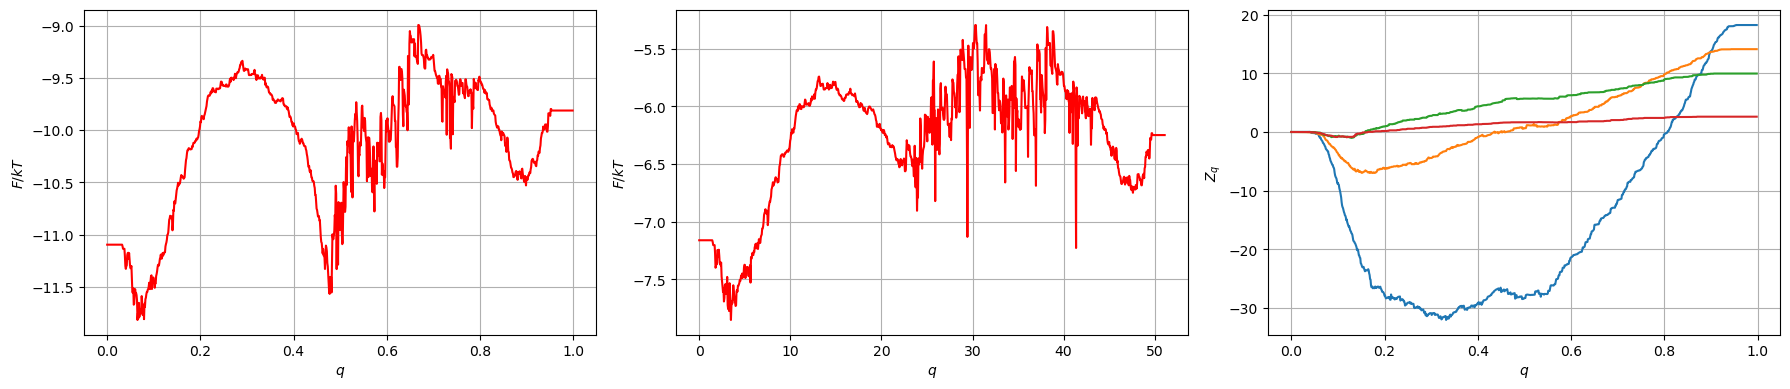

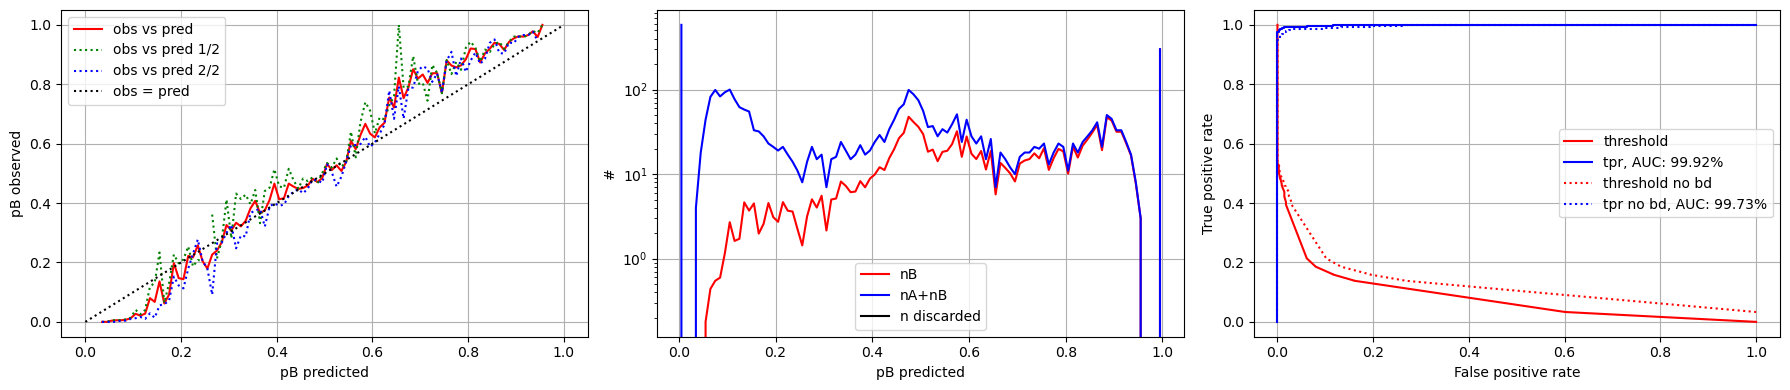

RUNNING NONLATENT
Rows=3831, trajectories=1452, boundary0=583, boundary1=300
#=2500, xent=0.217288, mse=0.0689776, sdzq=2.11872, dzq=5.19357, dr2=12.2011, auc=0.999224, |dx|=0.148532, time=2.82333
#=5000, xent=0.253969, mse=0.0859488, sdzq=3.13692, dzq=5.4014, dr2=16.0456, auc=0.999212, |dx|=0.0863137, time=5.64832
POST-OPTIMISATION


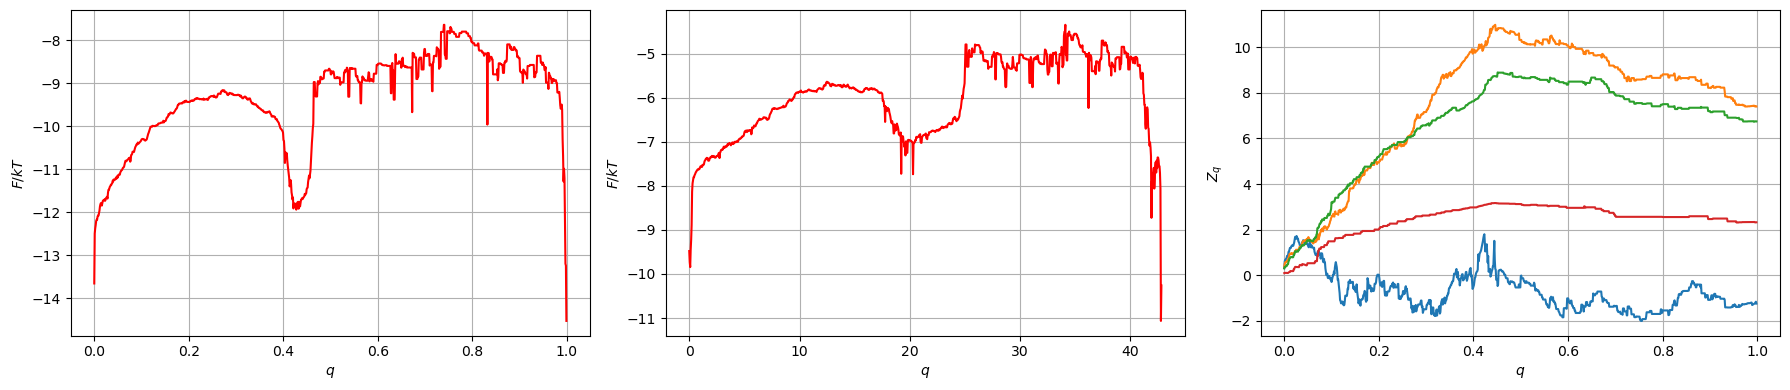

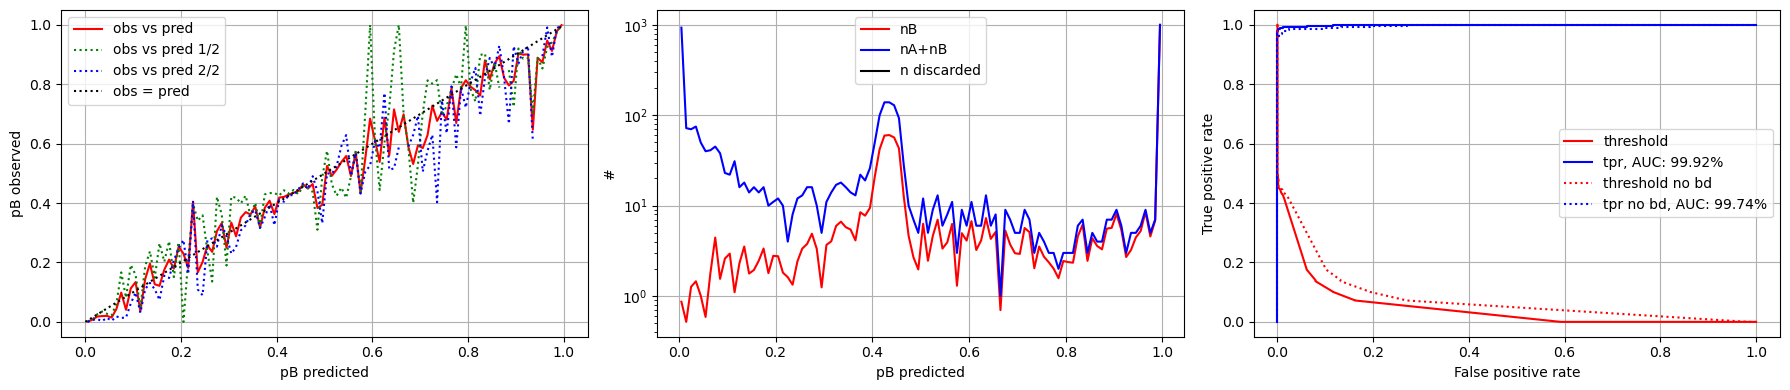

RUNNING LATENT
Rows=3831, trajectories=1452, boundary0=583, boundary1=300
#=2500, xent=0.231648, mse=0.0747892, sdzq=6.30056, dzq=10.0968, dr2=17.7714, auc=0.9996, |dx|=0.156596, time=2.90228
#=5000, xent=0.228588, mse=0.0745257, sdzq=1.5439, dzq=3.47768, dr2=8.66186, auc=0.999757, |dx|=0.126937, time=5.80503
POST-OPTIMISATION


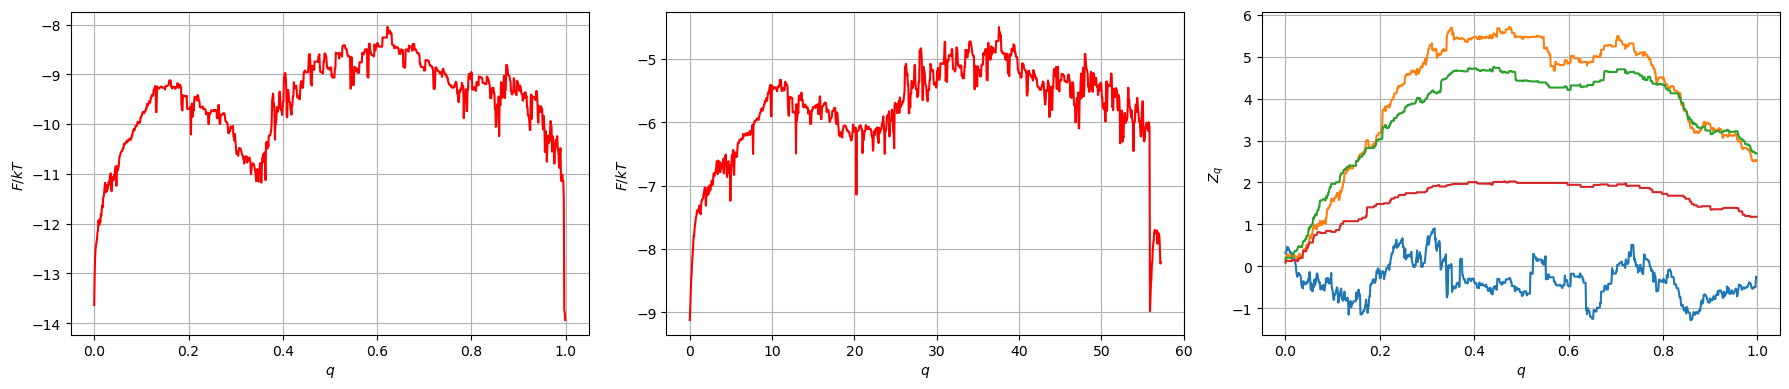

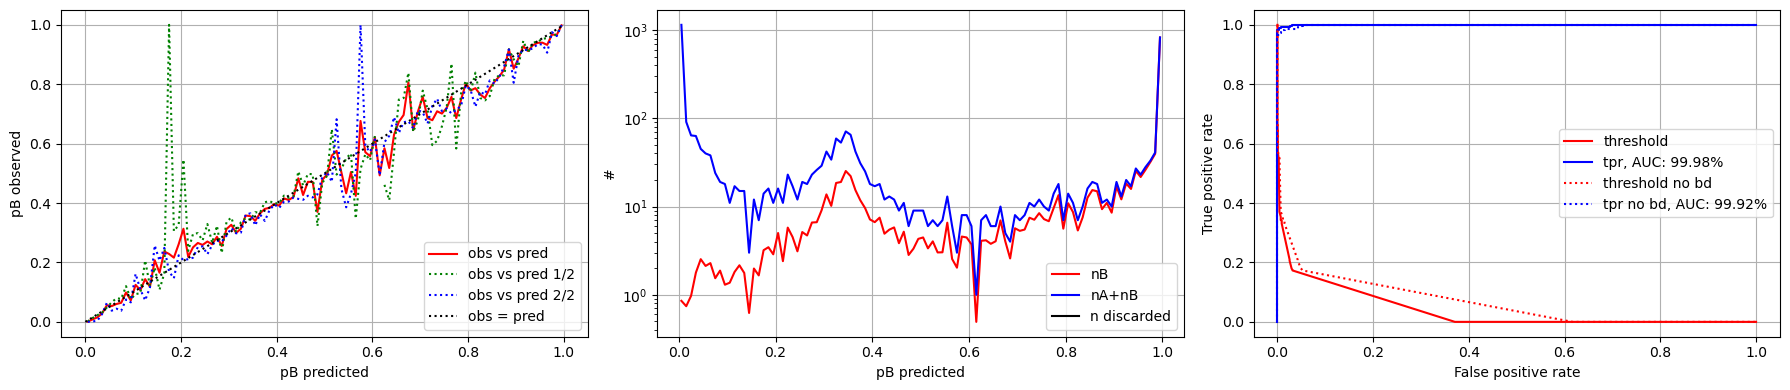

In [236]:
"""
# 97071 9979 good seeds for double peak
"""

q_transition_base, transition_base_summary, transition_base_df = plot_existing_model_transition_standard(
    df,
    q_col="pred_q",
    lag_times=[1, 2, 3, 4],
    trim_after_ad=True,
)

def run_opt(seeds=30):
    results = []

    history_delta_t = list(range(0, 4))
    
    history_type = [
        "y(t-d),r(t-d)",
        "lndt,r(t-d)",
        "lndt,y(t-d)",
        "lndt,r(t)",
        "lndt,y(t)",
    ]
    
    for i in range(seeds):
        print("RUNNING NONLATENT")
        q_transition_opt_nonlatent, transition_opt_summary_nonlatent, transition_opt_df_nonlatent = optimise_existing_model_transition_standard(
            df,
            lag_times=[1, 2, 3, 4],
            iterations=5000,
            gamma=0.1,
            print_step=2500,
            ny=2,
            envelope_size=1,
            seed=97071,
            y_matrix=None
        )
        
        print("RUNNING LATENT")
        q_transition_opt_latent, transition_opt_summary_latent, transition_opt_df_latent = optimise_existing_model_transition_standard(
            df,
            lag_times=[1, 2, 3, 4],
            iterations=5000,
            gamma=0.1,
            print_step=2500,
            ny=2,
            envelope_size=1,
            seed=97071,
            y_matrix=z_traj
        )
        
    return results

results = run_opt(1)

# Main Plan

- Premise of the report is about the dual purpose of using optimal RCs, both as an analysis tool to elucidate more information about machine learning models after they have been trained, as well as a potential source of improvement
  
- To begin, I'd talk about the selection of the existing model and dataset and why I chose them, followed by a short part about how I replicated the results of the paper. This would also explain AUC and its potential pitfalls in this application
  
- Next, I'd briefly talk about optimal RCs and how the method works (not too much mathematical detail but I would probably use the LaTeX laid out in your papers if appropriate)
  
- The next section would describe the changes I had to make to the input data to get it working, and I'd justify the use of latent representations as a potential secondary source of optimisation

  
- A short section on the latent representations and how I validated that they did follow a pattern with patient outcome, from when I used clustering, would follow.

  
- The next part would then discuss the reason I chose to use MFPT (one-way progression).


- To begin, an MFPT plot using the model's raw output will be shown. For those that progress to AD, their MFPT will be directly observed (0-60 months), while for MCI patients their MFPT

  
- This would be aided by the Kaplan-Meyer plots you mentioned which I am currently working on making.

  
- The overall aim would be to show that optimalrcs can be used to paint a comprehensive picture of how well a model interprets dynamics, and conclude with an evaluation of the original model chosen.
 

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp

try:
    import boundaries
except Exception:
    pass


def _to_np(x):
    return x.get() if hasattr(x, "get") else np.asarray(x)


def _refresh_q_boundaries(q):
    """Refresh cached boundary helpers after any manual r_traj selection."""
    if "boundaries" in globals():
        q.future_boundary = boundaries.FutureBoundary(q.r_traj, q.b_traj, q.t_traj, q.i_traj)
        q.past_boundary = boundaries.PastBoundary(q.r_traj, q.b_traj, q.t_traj, q.i_traj)
    return q


def _q_values(q):
    return np.asarray(_to_np(q.r_traj), dtype=float)


def _ids(df):
    return df["RID"].to_numpy()


def _times(df):
    return df["delta_t"].to_numpy(dtype=float)


def analysis_summary(q, summary, df, n_bins=20):
    """Summarise RC occupancy, boundaries, and Zq statistics."""
    r = _q_values(q)
    hist, edges = np.histogram(r, bins=np.linspace(0, 1, n_bins + 1))
    interior_hist = hist[1:-1]
    nonzero = interior_hist[interior_hist > 0]

    zq_stats = metrics._comp_max_delta_zq(
        q.r_traj, q.b_traj, q.i_traj, q.future_boundary, q.past_boundary,
        ldt=getattr(metrics, "ldt0", [1, 2, 3, 4]),
    )

    out = {
        "n_rows": len(df),
        "n_trajectories": df["RID"].nunique(),
        "n_boundary0": int(np.sum(_to_np(q.boundary0))),
        "n_boundary1": int(np.sum(_to_np(q.boundary1))),
        "filled_bins": int(np.sum(hist > 0)),
        "interior_bins": int(np.sum(interior_hist > 0)),
        "min_interior_count": int(nonzero.min()) if len(nonzero) else 0,
        "interior_frac": float(np.mean((r > 0.05) & (r < 0.95))),
        "edge_frac": float(np.mean((r <= 0.05) | (r >= 0.95))),
        "max_abs_zq_deviation": float(zq_stats[0]),
        "max_abs_zq_lag": int(zq_stats[1]),
        "max_sd_zq": float(zq_stats[2]),
        "max_sd_zq_lag": int(zq_stats[3]),
        "total_zq_variance": float(zq_stats[4]),
    }

    print(pd.Series(out))
    return out


def plot_standard_diagnostics(q, lag_times=(1, 2, 3, 4), log_obs=True):
    """Run the standard Krivov-style FEP/Zq and observed-vs-predicted plots."""
    _refresh_q_boundaries(q)

    print("FEP / natural FEP / Zq")
    q.plots_feps(ldt=list(lag_times))

    print("Observed vs predicted")
    q.plots_obs_pred()

    if log_obs:
        print("Observed vs predicted, log scale")
        q.plots_obs_pred(log_scale=True, log_scale_pmin=1e-4)


def plot_zq_only(q, lag_times=(1, 2, 3, 4)):
    """Plot Zq profiles directly for the chosen lag times."""
    _refresh_q_boundaries(q)

    fig, ax = plt.subplots(figsize=(7, 5))
    plots.plot_zq(
        ax,
        q.r_traj,
        q.b_traj,
        q.i_traj,
        q.future_boundary,
        q.past_boundary,
        ldt=list(lag_times),
        xlabel="$q$",
    )
    ax.set_title("Zq profiles")
    plt.tight_layout()
    plt.show()


def plot_q_first_vs_k_last(q, df, k=1, log_q=False):
    """Compare each trajectory's first q with its kth-from-last q."""
    r = _q_values(q)
    ids = _ids(df)

    x, y = [], []

    for rid in pd.unique(ids):
        idx = np.where(ids == rid)[0]
        if len(idx) <= k:
            continue
        x.append(r[idx[0]])
        y.append(r[idx[-k]])

    x = np.asarray(x)
    y = np.asarray(y)

    if log_q:
        x = np.log(x + 1e-5)
        y = np.log(y + 1e-5)
        xlabel = "log(first q + 1e-5)"
        ylabel = f"log({k}-last q + 1e-5)"
    else:
        xlabel = "first q"
        ylabel = f"{k}-last q"

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(x, y, s=8, alpha=0.35)
    ax.set(xlabel=xlabel, ylabel=ylabel, title=f"First q vs {k}-last q")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_k_last_given_first_ranges(
    q,
    df,
    k=1,
    first_ranges=((0.15, 0.25), (0.45, 0.55), (0.75, 0.85)),
    bins=30,
    density=False,
):
    """Plot kth-from-last q distributions for selected initial-q ranges."""
    r = _q_values(q)
    ids = _ids(df)

    first_q = []
    last_q = []

    for rid in pd.unique(ids):
        idx = np.where(ids == rid)[0]
        if len(idx) <= k:
            continue
        first_q.append(r[idx[0]])
        last_q.append(r[idx[-k]])

    first_q = np.asarray(first_q)
    last_q = np.asarray(last_q)

    fig, axes = plt.subplots(1, len(first_ranges), figsize=(5 * len(first_ranges), 4), sharey=not density)
    if len(first_ranges) == 1:
        axes = [axes]

    for ax, rg in zip(axes, first_ranges):
        mask = (first_q >= rg[0]) & (first_q <= rg[1])
        vals = last_q[mask]
        ax.hist(vals, bins=bins, range=(0, 1), density=density, alpha=0.75)
        ax.set(
            title=f"first q in [{rg[0]}, {rg[1]}], n={len(vals)}",
            xlabel=f"{k}-last q",
            ylabel="density" if density else "count",
        )
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def expected_metrics_from_q(q_values, thresholds=None):
    """Expected threshold metrics using q itself as the probability of B."""
    qv = np.clip(np.asarray(q_values, dtype=float), 0.0, 1.0)

    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)

    rows = []
    P = qv.sum()
    N = (1.0 - qv).sum()

    for t in thresholds:
        pred_pos = qv >= t
        pred_neg = ~pred_pos

        TP = qv[pred_pos].sum()
        FP = (1.0 - qv[pred_pos]).sum()
        TN = (1.0 - qv[pred_neg]).sum()
        FN = qv[pred_neg].sum()

        precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
        recall = TP / P if P > 0 else np.nan
        fpr = FP / N if N > 0 else np.nan
        specificity = TN / N if N > 0 else np.nan

        rows.append({
            "threshold": t,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "precision": precision,
            "recall": recall,
            "sensitivity": recall,
            "specificity": specificity,
            "fpr": fpr,
            "accuracy": (TP + TN) / (P + N) if (P + N) > 0 else np.nan,
            "f1": 2 * precision * recall / (precision + recall)
                  if precision == precision and recall == recall and (precision + recall) > 0
                  else np.nan,
        })

    return pd.DataFrame(rows)


def plot_expected_roc_pr(q):
    """Plot ROC/PR using explicit NumPy conversion to avoid CuPy sklearn errors."""
    import sklearn.metrics

    r = _q_values(q)
    em = expected_metrics_from_q(r)

    fb_index = _to_np(q.future_boundary.index)
    fb_r = _to_np(q.future_boundary.r)
    ok = fb_index > -1

    y_true = fb_r[ok].astype(int)
    y_score = r[ok]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fpr, tpr, _ = sklearn.metrics.roc_curve(y_true, y_score)
    auc_roc = sklearn.metrics.auc(fpr, tpr)

    axes[0].plot(fpr, tpr, "r-", label=f"observed ROC AUC={auc_roc:.3f}")
    axes[0].plot(em["fpr"], em["recall"], "k--", label="expected from q")
    axes[0].plot([0, 1], [0, 1], ":k")
    axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    precision, recall, _ = sklearn.metrics.precision_recall_curve(y_true, y_score)
    auc_pr = sklearn.metrics.auc(recall, precision)

    axes[1].plot(recall, precision, "r-", label=f"observed PR AUC={auc_pr:.3f}")
    axes[1].plot(em["recall"], em["precision"], "k--", label="expected from q")
    axes[1].set(xlabel="recall", ylabel="precision", title="Precision-recall")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return em



def trajectory_event_table(q, df, time_scale=1.0):
    """Build per-trajectory first-q, event/censor time, and terminal status."""
    r = _q_values(q)
    ids = _ids(df)
    t = _times(df)

    b0 = np.asarray(_to_np(q.boundary0), dtype=bool)
    b1 = np.asarray(_to_np(q.boundary1), dtype=bool)

    rows = []

    for rid in pd.unique(ids):
        idx = np.where(ids == rid)[0]
        first = idx[0]

        hit_b1 = idx[b1[idx]]
        hit_b0 = idx[b0[idx]]

        if len(hit_b1):
            terminal_idx = hit_b1[0]
            event = 1
            terminal = "B"
        elif len(hit_b0):
            terminal_idx = hit_b0[-1]
            event = 0
            terminal = "A"
        else:
            terminal_idx = idx[-1]
            event = 0
            terminal = "censored"

        rows.append({
            "RID": rid,
            "q_first": r[first],
            "q_last": r[idx[-1]],
            "time": max(0.0, (t[terminal_idx] - t[first]) / time_scale),
            "event_B": event,
            "terminal": terminal,
            "n_visits": len(idx),
        })

    return pd.DataFrame(rows)


def plot_tpt_q(q, df, q_bins=(0.0, 0.25, 0.5, 0.75, 1.0), time_scale=1.0):
    """Plot observed time-to-B distributions stratified by initial q."""
    tab = trajectory_event_table(q, df, time_scale=time_scale)
    ev = tab[tab["event_B"] == 1].copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    for lo, hi in zip(q_bins[:-1], q_bins[1:]):
        vals = ev[(ev["q_first"] >= lo) & (ev["q_first"] < hi)]["time"].to_numpy()
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=20, alpha=0.45, density=True, label=f"q0 [{lo:.2f}, {hi:.2f}), n={len(vals)}")

    ax.set(xlabel=f"time to B / {time_scale}", ylabel="density", title="Transition-time distribution by initial q")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return tab


def _km_curve(times, events):
    order = np.argsort(times)
    times = np.asarray(times)[order]
    events = np.asarray(events)[order].astype(bool)

    surv = 1.0
    xs = [0.0]
    ys = [1.0]

    for tt in np.unique(times):
        at_risk = np.sum(times >= tt)
        d = np.sum((times == tt) & events)
        if at_risk > 0:
            surv *= (1.0 - d / at_risk)
        xs.append(tt)
        ys.append(surv)

    return np.asarray(xs), np.asarray(ys)


def plot_survival_by_initial_q(q, df, n_bins=4, time_scale=1.0):
    """Kaplan-Meier-style B-free survival stratified by initial q."""
    tab = trajectory_event_table(q, df, time_scale=time_scale)
    edges = np.quantile(tab["q_first"], np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-12
    edges[-1] += 1e-12

    fig, ax = plt.subplots(figsize=(8, 5))

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        grp = tab[(tab["q_first"] >= lo) & (tab["q_first"] < hi)]
        if len(grp) == 0:
            continue
        x, y = _km_curve(grp["time"].to_numpy(), grp["event_B"].to_numpy())
        ax.step(x, y, where="post", label=f"q0 [{lo:.2f}, {hi:.2f}), n={len(grp)}")

    ax.set(xlabel=f"time / {time_scale}", ylabel="P(not B yet)", title="B-free survival by initial q")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return tab


def plot_patient_trajectories(
    q,
    df,
    n_patients=10,
    seed=0,
    qrange=None,
    converters_only=False,
):
    """Plot selected patient q trajectories over delta_t."""
    r = _q_values(q)
    ids = _ids(df)
    t = _times(df)
    dx = df["FollowupDX"].to_numpy() if "FollowupDX" in df.columns else None

    b1 = np.asarray(_to_np(q.boundary1), dtype=bool)

    candidates = []

    for rid in pd.unique(ids):
        idx = np.where(ids == rid)[0]
        if len(idx) < 2:
            continue

        if converters_only and not np.any(b1[idx]):
            continue

        if qrange is not None:
            if not np.any((r[idx] >= qrange[0]) & (r[idx] <= qrange[1])):
                continue

        candidates.append(rid)

    if len(candidates) == 0:
        print("No matching patient trajectories.")
        return []

    rng = np.random.default_rng(seed)
    chosen = rng.choice(candidates, size=min(n_patients, len(candidates)), replace=False)

    fig, ax = plt.subplots(figsize=(10, 6))

    for rid in chosen:
        idx = np.where(ids == rid)[0]
        ax.plot(t[idx], r[idx], marker="o", lw=1.2, alpha=0.8, label=str(rid))

        if dx is not None:
            for j in idx:
                if dx[j] == 2:
                    ax.scatter(t[j], r[j], color="red", s=30, zorder=5)
                elif dx[j] == 1:
                    ax.scatter(t[j], r[j], color="orange", s=20, zorder=5)
                elif dx[j] == 0:
                    ax.scatter(t[j], r[j], color="green", s=20, zorder=5)

    ax.set(xlabel="delta_t", ylabel="q", title="Patient committor trajectories")
    ax.grid(alpha=0.3)
    if len(chosen) <= 12:
        ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

    return chosen


def plot_rc_histograms(q, df, k=1):
    """Histogram first q, last q, and kth-from-last q."""
    r = _q_values(q)
    ids = _ids(df)

    first_vals, last_vals, klast_vals = [], [], []

    for rid in pd.unique(ids):
        idx = np.where(ids == rid)[0]
        first_vals.append(r[idx[0]])
        last_vals.append(r[idx[-1]])
        if len(idx) > k:
            klast_vals.append(r[idx[-k]])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(first_vals, bins=30, range=(0, 1), alpha=0.8)
    axes[0].set(title="first q", xlabel="q", ylabel="count")

    axes[1].hist(klast_vals, bins=30, range=(0, 1), alpha=0.8)
    axes[1].set(title=f"{k}-last q", xlabel="q")

    axes[2].hist(last_vals, bins=30, range=(0, 1), alpha=0.8)
    axes[2].set(title="last q", xlabel="q")

    for ax in axes:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def run_full_transition_post_analysis_compare(
    q_base,
    q_latent,
    q_nonlatent,
    base_summary=None,
    latent_summary=None,
    nonlatent_summary=None,
    base_df=None,
    latent_df=None,
    nonlatent_df=None,
    lag_times=(1, 2, 3, 4),
    time_scale=1.0,
    n_survival_bins=5,
):
    """Run post-analysis for base, latent-optimised, and nonlatent-optimised q objects."""
    models = {
        "base": {
            "q": q_base,
            "summary": base_summary if base_summary is not None else {},
            "df": base_df,
        },
        "optimised_latent": {
            "q": q_latent,
            "summary": latent_summary if latent_summary is not None else {},
            "df": latent_df,
        },
        "optimised_nonlatent": {
            "q": q_nonlatent,
            "summary": nonlatent_summary if nonlatent_summary is not None else {},
            "df": nonlatent_df,
        },
    }

    outputs = {}

    for name, obj in models.items():
        print("\n" + "=" * 100)
        print(f"MODEL: {name}")
        print("=" * 100)

        q = _refresh_q_boundaries(obj["q"])

        if obj["df"] is None:
            raise ValueError(f"Missing dataframe for {name}")

        model_df = obj["df"].reset_index(drop=True)

        outputs[name] = run_full_transition_post_analysis(
            q,
            obj["summary"],
            model_df,
            lag_times=lag_times,
            time_scale=time_scale,
            n_survival_bins=n_survival_bins,
        )

    print("\n" + "=" * 100)
    print("SURVIVAL MODEL COMPARISON")
    print("=" * 100)

    survival_scores = {}

    for name, obj in models.items():
        survival_scores[name] = survival_model_scores_from_q(
            obj["q"],
            obj["df"],
            n_bins=n_survival_bins,
            time_scale=time_scale,
        )

    comparison = pd.DataFrame([
        {
            "model": name,
            "c_index": scores["c_index"],
            "monotonicity": scores["monotonicity"],
            "event_spread": scores["event_spread"],
            "n_patients": scores["n_patients"],
            "n_events": scores["n_events"],
        }
        for name, scores in survival_scores.items()
    ]).sort_values(
        ["c_index", "monotonicity", "event_spread"],
        ascending=[False, False, False],
    )

    print(comparison)

    outputs["survival_scores"] = survival_scores
    outputs["survival_comparison"] = comparison

    print("\n" + "=" * 100)
    print("SURVIVAL PLOTS")
    print("=" * 100)

    for name, scores in survival_scores.items():
        plot_survival_single_model(scores, name, n_bins=n_survival_bins)

    return outputs


In [185]:
def plot_survival_comparison_optimised_vs_unoptimised(
    q_optimised,
    transition_df,
    q_col="pred_q",
    n_bins=5,
    time_scale=1.0,
    title_suffix="",
):
    """Compare B-free survival by initial q for unoptimised pred_q vs optimised q."""
    df = transition_df.reset_index(drop=True).copy()

    ids = df["RID"].to_numpy()
    times = df["delta_t"].to_numpy(dtype=float)

    r_opt = _q_values(q_optimised)
    r_base = np.clip(df[q_col].to_numpy(dtype=float), 0.0, 1.0)

    b1 = np.asarray(_to_np(q_optimised.boundary1), dtype=bool)

    def make_table(r):
        rows = []

        for rid in pd.unique(ids):
            idx = np.where(ids == rid)[0]
            first = idx[0]

            hit_b = idx[b1[idx]]

            if len(hit_b) > 0:
                event_idx = hit_b[0]
                event = 1
            else:
                event_idx = idx[-1]
                event = 0

            rows.append({
                "RID": rid,
                "q_first": r[first],
                "time": max(0.0, (times[event_idx] - times[first]) / time_scale),
                "event_B": event,
            })

        return pd.DataFrame(rows)

    def km_curve(times_, events_):
        times_ = np.asarray(times_, dtype=float)
        events_ = np.asarray(events_, dtype=bool)

        order = np.argsort(times_)
        times_ = times_[order]
        events_ = events_[order]

        surv = 1.0
        xs = [0.0]
        ys = [1.0]

        for tt in np.unique(times_):
            at_risk = np.sum(times_ >= tt)
            deaths = np.sum((times_ == tt) & events_)

            if at_risk > 0:
                surv *= 1.0 - deaths / at_risk

            xs.append(tt)
            ys.append(surv)

        return np.asarray(xs), np.asarray(ys)

    tab_base = make_table(r_base)
    tab_opt = make_table(r_opt)

    # Shared strata from baseline+optimised initial q distribution
    all_q = np.r_[tab_base["q_first"].to_numpy(), tab_opt["q_first"].to_numpy()]
    edges = np.quantile(all_q, np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-12
    edges[-1] += 1e-12

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, tab, title in [
        (axes[0], tab_base, "Unoptimised pred_q"),
        (axes[1], tab_opt, "Optimised q"),
    ]:
        for i in range(n_bins):
            lo, hi = edges[i], edges[i + 1]
            grp = tab[(tab["q_first"] >= lo) & (tab["q_first"] < hi)]

            if len(grp) == 0:
                continue

            x, y = km_curve(grp["time"], grp["event_B"])
            ax.step(
                x,
                y,
                where="post",
                label=f"q0 [{lo:.2f}, {hi:.2f}), n={len(grp)}, events={grp['event_B'].sum()}",
            )

        ax.set(
            title=title + title_suffix,
            xlabel=f"time / {time_scale}",
            ylabel="P(not reaching AD)" if ax is axes[0] else None,
        )
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    return {
        "unoptimised": tab_base,
        "optimised": tab_opt,
        "bin_edges": edges,
    }


In [199]:
def assign_fixed_q_bins(tab, n_bins=5, q_col="q_first"):
    """Assign fixed-width q bins of width 1 / n_bins."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    labels = [f"[{edges[i]:.2f}, {edges[i+1]:.2f})" for i in range(n_bins)]
    labels[-1] = f"[{edges[-2]:.2f}, {edges[-1]:.2f}]"

    tab = tab.copy()
    tab["bin"] = pd.cut(
        tab[q_col],
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=False,
    )

    tab.loc[tab[q_col] >= 1.0, "bin"] = labels[-1]
    tab = tab.dropna(subset=["bin"])

    return tab, edges


def survival_model_scores_fixed_bins(
    q_obj,
    data_df,
    q_values=None,
    n_bins=5,
    time_scale=1.0,
):
    """Compute survival scores using fixed-width q bins."""
    n = len(q_obj.r_traj)

    work = data_df.sort_values(["RID", "delta_t"]).reset_index(drop=True).iloc[:n].copy()

    if q_values is None:
        q_values = _q_values(q_obj)
    else:
        q_values = np.asarray(q_values, dtype=float)[:n]

    ids = work["RID"].to_numpy()
    times = work["delta_t"].to_numpy(dtype=float)
    b1 = np.asarray(_to_np(q_obj.boundary1), dtype=bool)

    rows = []

    for rid in pd.unique(ids):
        idx = np.where(ids == rid)[0]
        first = idx[0]
        hit = idx[b1[idx]]

        if len(hit) > 0:
            event_idx = hit[0]
            event = 1
        else:
            event_idx = idx[-1]
            event = 0

        rows.append({
            "RID": rid,
            "q_first": q_values[first],
            "time": max(0.0, (times[event_idx] - times[first]) / time_scale),
            "event": event,
        })

    tab = pd.DataFrame(rows)
    tab, edges = assign_fixed_q_bins(tab, n_bins=n_bins, q_col="q_first")

    concordant = discordant = tied = comparable = 0
    arr = tab[["q_first", "time", "event"]].to_numpy()

    for i in range(len(arr)):
        qi, ti, ei = arr[i]
        for j in range(i + 1, len(arr)):
            qj, tj, ej = arr[j]

            if ei == 1 and ti < tj:
                comparable += 1
                if qi > qj:
                    concordant += 1
                elif qi < qj:
                    discordant += 1
                else:
                    tied += 1

            elif ej == 1 and tj < ti:
                comparable += 1
                if qj > qi:
                    concordant += 1
                elif qj < qi:
                    discordant += 1
                else:
                    tied += 1

    c_index = (concordant + 0.5 * tied) / comparable if comparable > 0 else np.nan

    bin_stats = (
        tab.groupby("bin", observed=True)
        .agg(
            n=("RID", "count"),
            events=("event", "sum"),
            event_rate=("event", "mean"),
            mean_time=("time", "mean"),
            median_time=("time", "median"),
            mean_q=("q_first", "mean"),
        )
        .reset_index()
    )

    event_rates = bin_stats["event_rate"].to_numpy()
    monotonicity = np.sum(np.diff(event_rates) >= 0) / max(1, len(event_rates) - 1)

    event_spread = np.average(
        (event_rates - tab["event"].mean()) ** 2,
        weights=bin_stats["n"],
    ) if len(bin_stats) > 0 else np.nan

    return {
        "table": tab,
        "bin_stats": bin_stats,
        "bin_edges": edges,
        "c_index": float(c_index),
        "monotonicity": float(monotonicity),
        "event_spread": float(event_spread),
        "n_patients": int(len(tab)),
        "n_events": int(tab["event"].sum()),
    }


def plot_survival_single_model_fixed_bins(score_dict, model_name):
    """Plot KM-style survival curves using precomputed fixed-width q bins."""
    tab = score_dict["table"].copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    for bin_label, grp in tab.groupby("bin", observed=True):
        times = grp["time"].to_numpy(dtype=float)
        events = grp["event"].to_numpy(dtype=bool)

        order = np.argsort(times)
        times = times[order]
        events = events[order]

        surv = 1.0
        xs = [0.0]
        ys = [1.0]

        for tt in np.unique(times):
            at_risk = np.sum(times >= tt)
            deaths = np.sum((times == tt) & events)

            if at_risk > 0:
                surv *= 1.0 - deaths / at_risk

            xs.append(tt)
            ys.append(surv)

        ax.step(
            xs,
            ys,
            where="post",
            label=f"{bin_label}, n={len(grp)}, events={grp['event'].sum()}",
        )

    ax.set(
        title=f"{model_name} survival by fixed-width initial q bins",
        xlabel="time",
        ylabel="P(not reaching AD)",
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_survival_comparison_fixed_bins(
    model_dict,
    n_bins=5,
    time_scale=1.0,
):
    """
    Compare multiple models using fixed-width q bins.

    model_dict format:
    {
        "base": (q_base, df_base),
        "latent": (q_latent, df_latent),
        "nonlatent": (q_nonlatent, df_nonlatent),
    }
    """
    scores = {}

    for name, (q_obj, model_df) in model_dict.items():
        scores[name] = survival_model_scores_fixed_bins(
            q_obj,
            model_df,
            n_bins=n_bins,
            time_scale=time_scale,
        )

    comparison = pd.DataFrame([
        {
            "model": name,
            "c_index": s["c_index"],
            "monotonicity": s["monotonicity"],
            "event_spread": s["event_spread"],
            "n_patients": s["n_patients"],
            "n_events": s["n_events"],
        }
        for name, s in scores.items()
    ]).sort_values(
        ["c_index", "monotonicity", "event_spread"],
        ascending=[False, False, False],
    )

    print(comparison)

    for name, s in scores.items():
        plot_survival_single_model_fixed_bins(s, name)

    return scores, comparison



MODEL: base

=== Summary ===
n_rows                  3831.000000
n_trajectories          1452.000000
n_boundary0              583.000000
n_boundary1              300.000000
filled_bins               20.000000
interior_bins             18.000000
min_interior_count        62.000000
interior_frac              0.762986
edge_frac                  0.237014
max_abs_zq_deviation      31.833921
max_abs_zq_lag             1.000000
max_sd_zq                 16.051355
max_sd_zq_lag              1.000000
total_zq_variance        315.064283
dtype: float64

=== Standard diagnostics ===
FEP / natural FEP / Zq


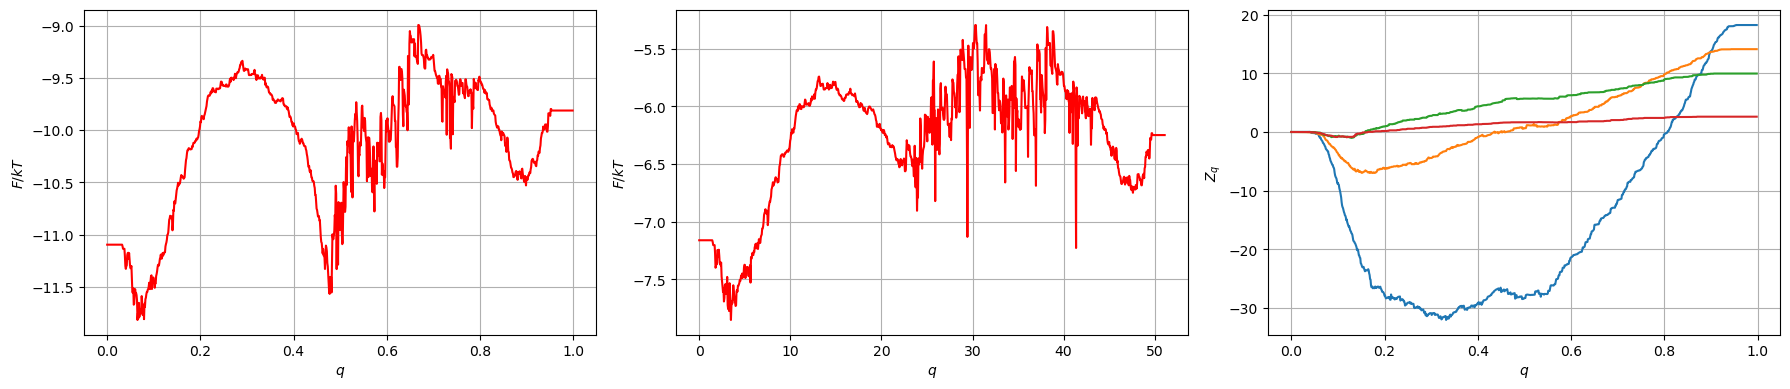

Observed vs predicted


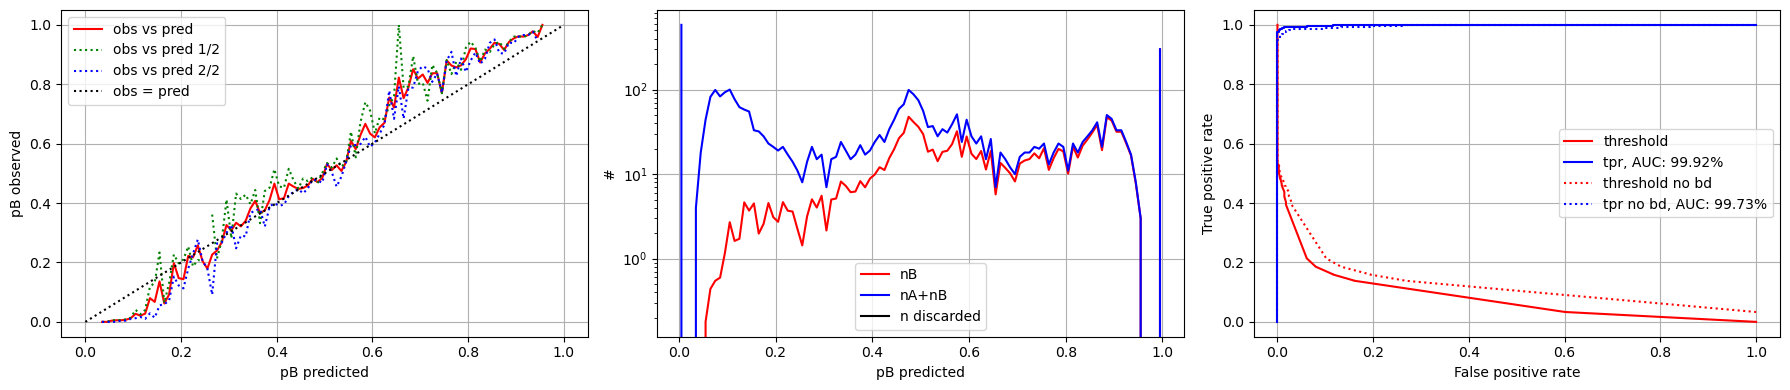

Observed vs predicted, log scale


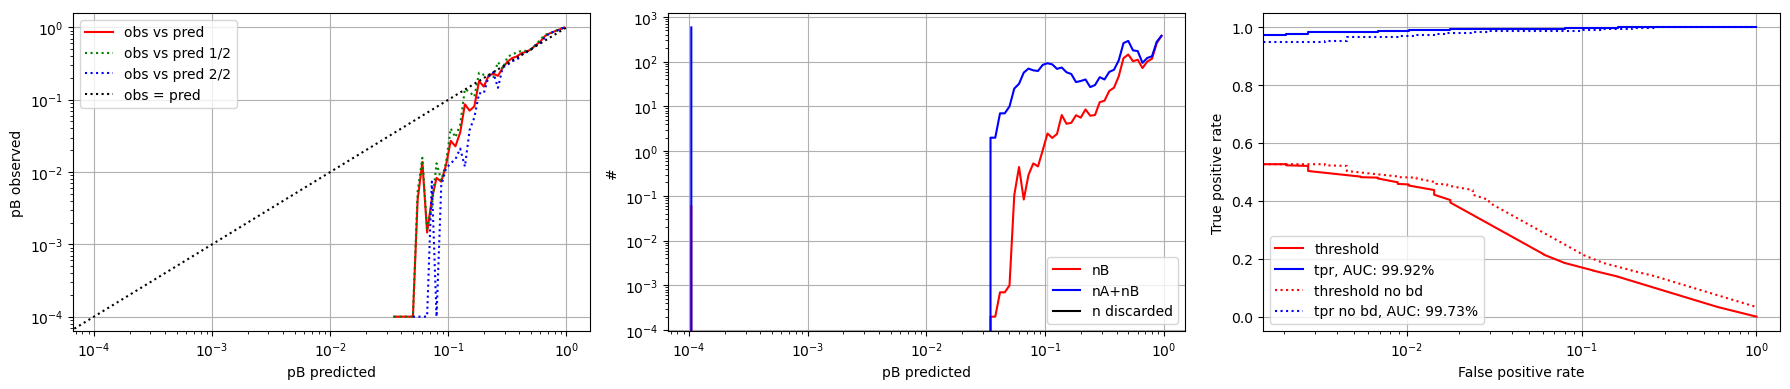


=== Zq only ===


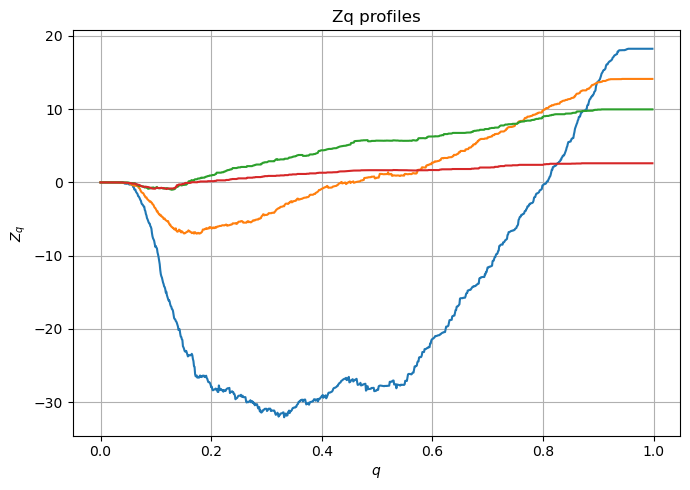


=== q histograms ===


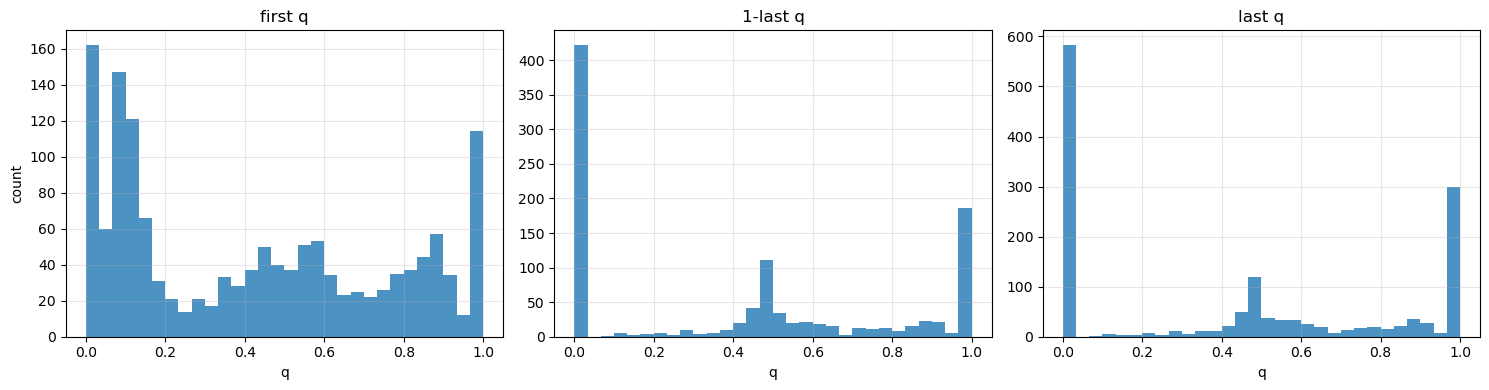


=== First vs kth-last q ===


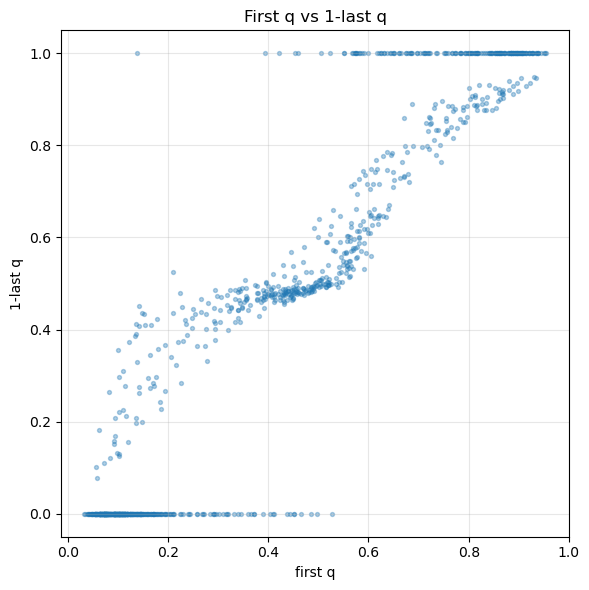

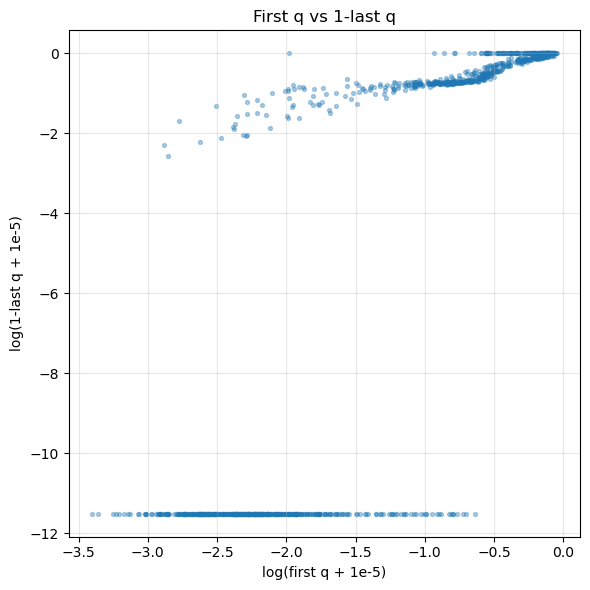


=== kth-last distributions by first-q bin ===


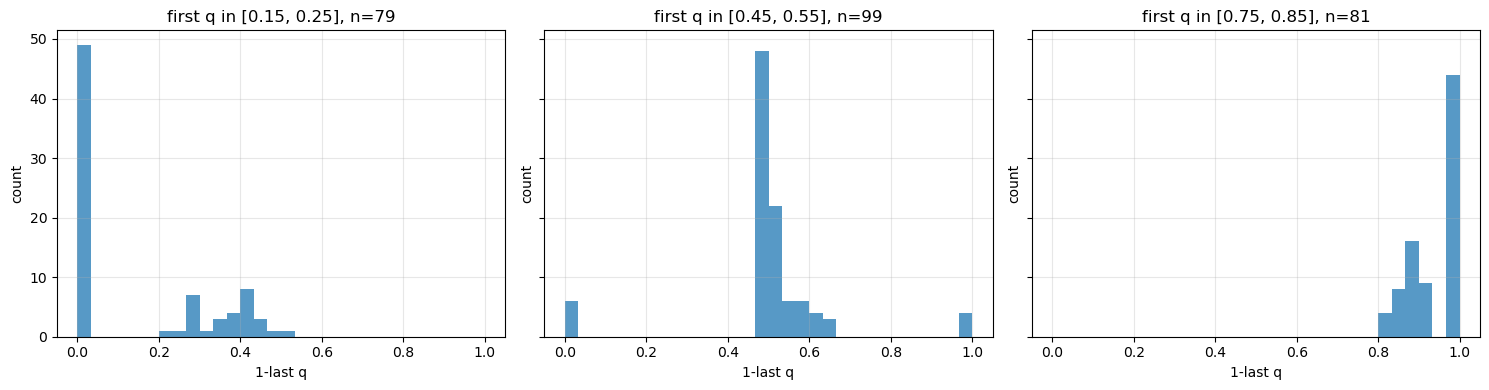


=== ROC / PR ===


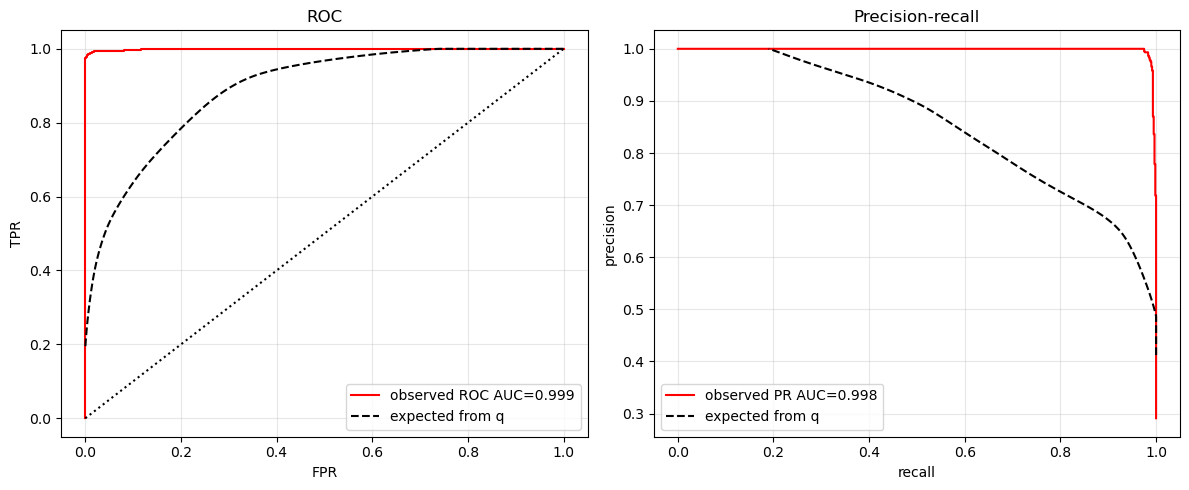


=== Transition-time distribution ===


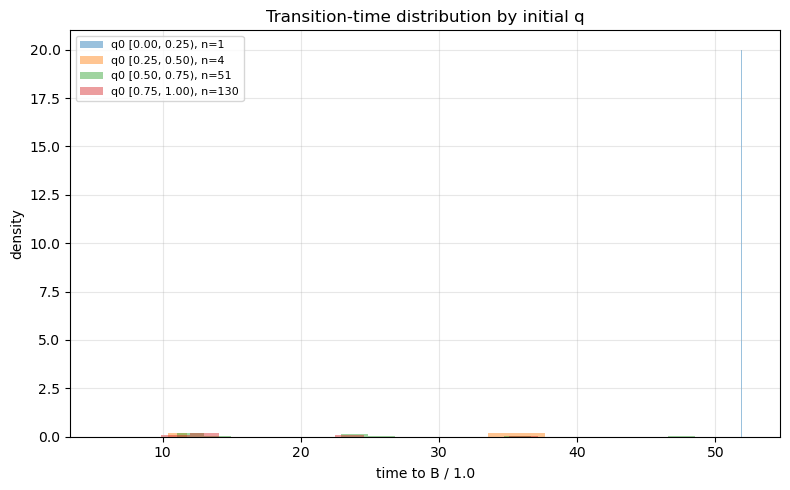


=== Example converter trajectories ===


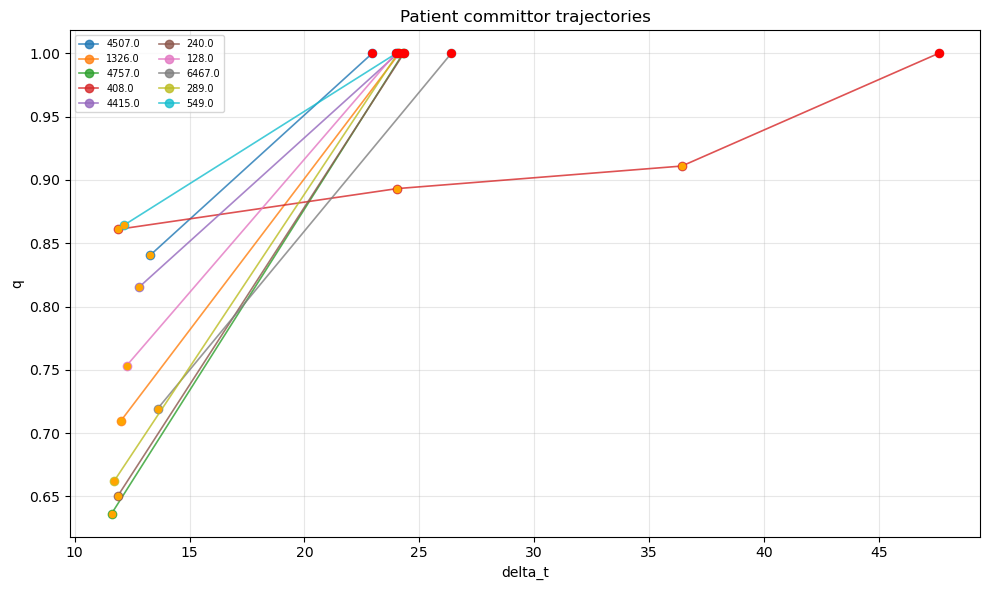


=== Example mid-q trajectories ===


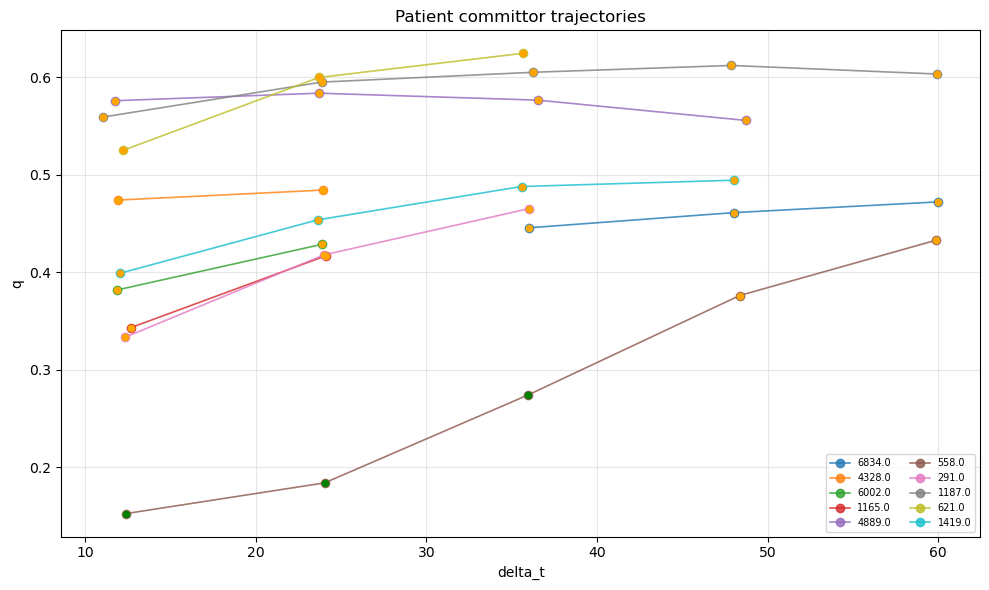


MODEL: optimised_latent

=== Summary ===
n_rows                  3831.000000
n_trajectories          1452.000000
n_boundary0              583.000000
n_boundary1              300.000000
filled_bins               20.000000
interior_bins             18.000000
min_interior_count         7.000000
interior_frac              0.206735
edge_frac                  0.793265
max_abs_zq_deviation       9.530883
max_abs_zq_lag             2.000000
max_sd_zq                  3.857075
max_sd_zq_lag              2.000000
total_zq_variance         24.383894
dtype: float64

=== Standard diagnostics ===
FEP / natural FEP / Zq


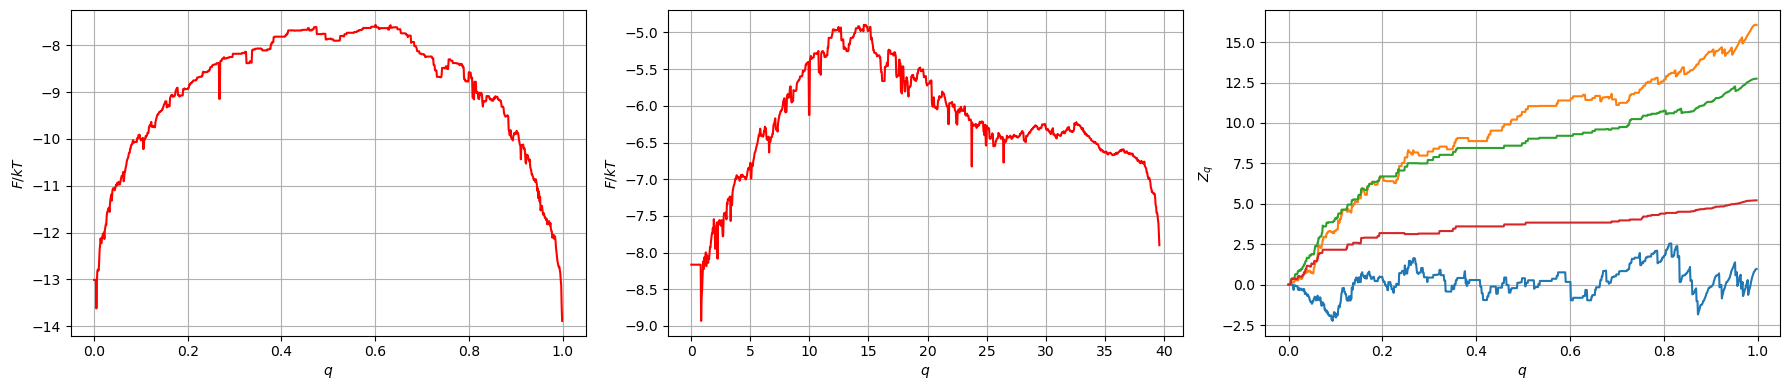

Observed vs predicted


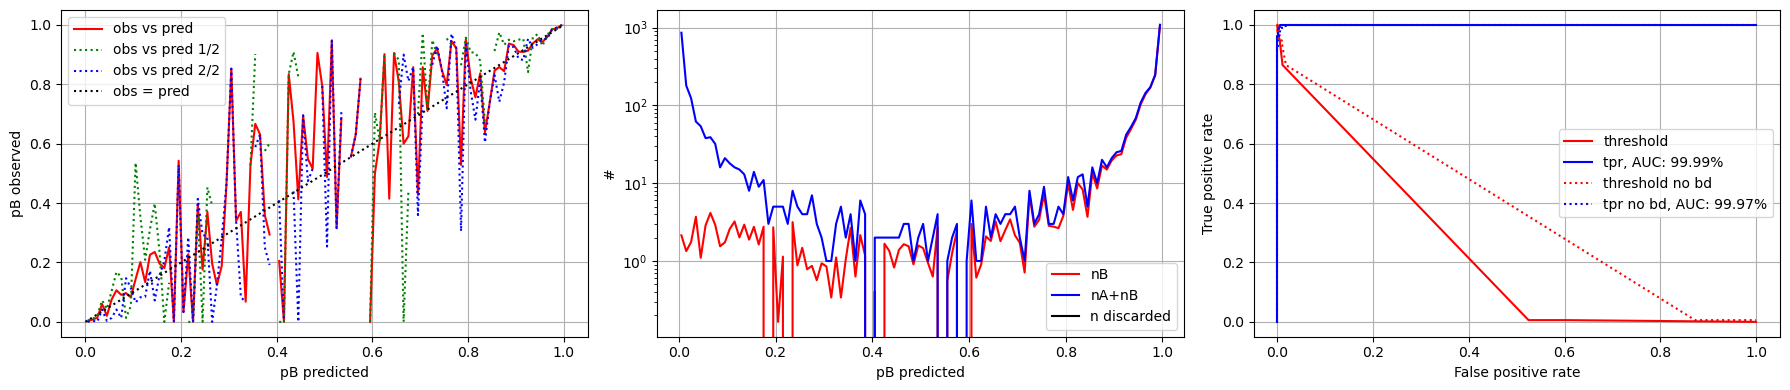

Observed vs predicted, log scale


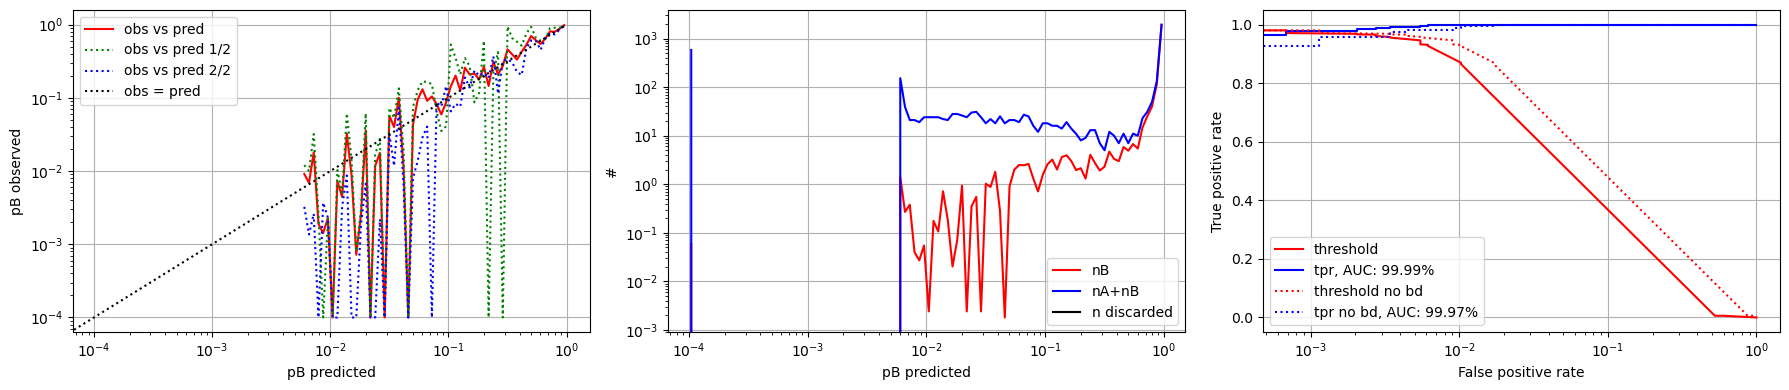


=== Zq only ===


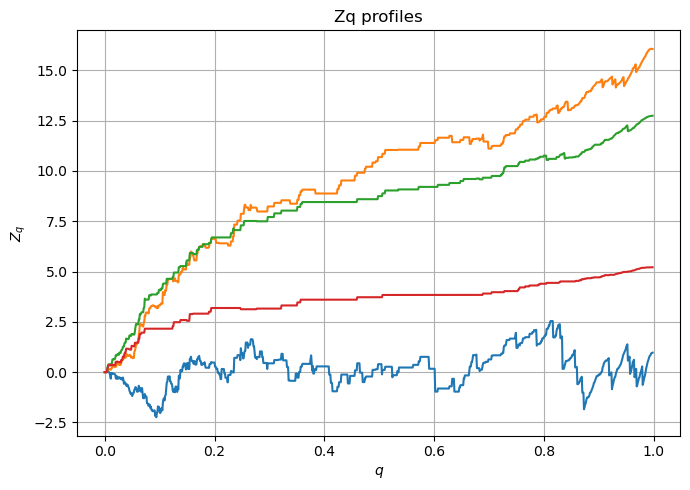


=== q histograms ===


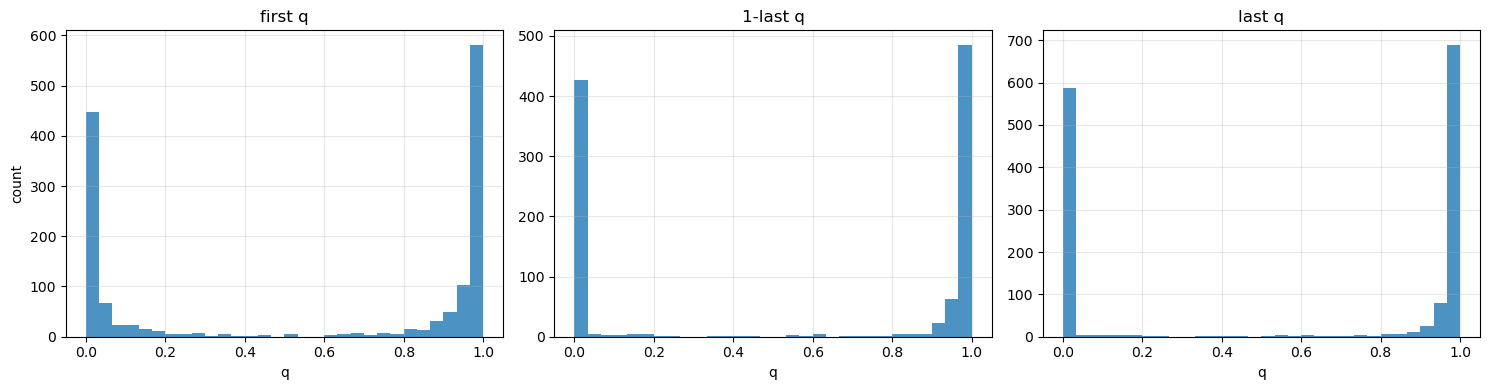


=== First vs kth-last q ===


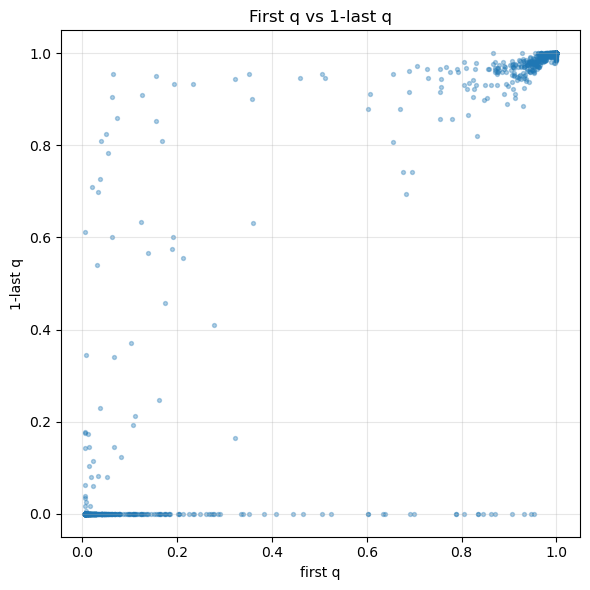

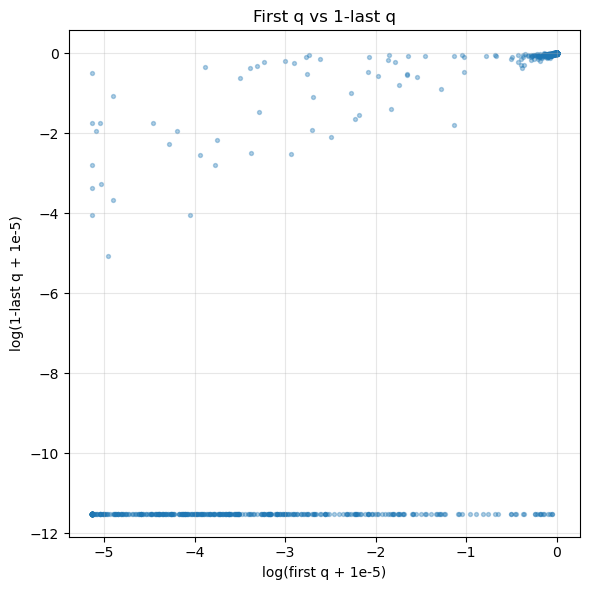


=== kth-last distributions by first-q bin ===


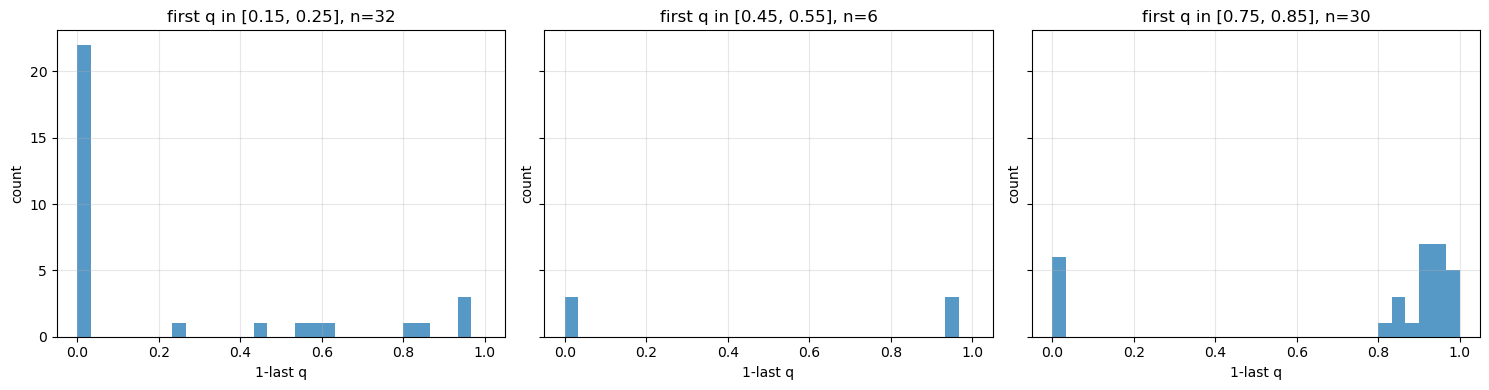


=== ROC / PR ===


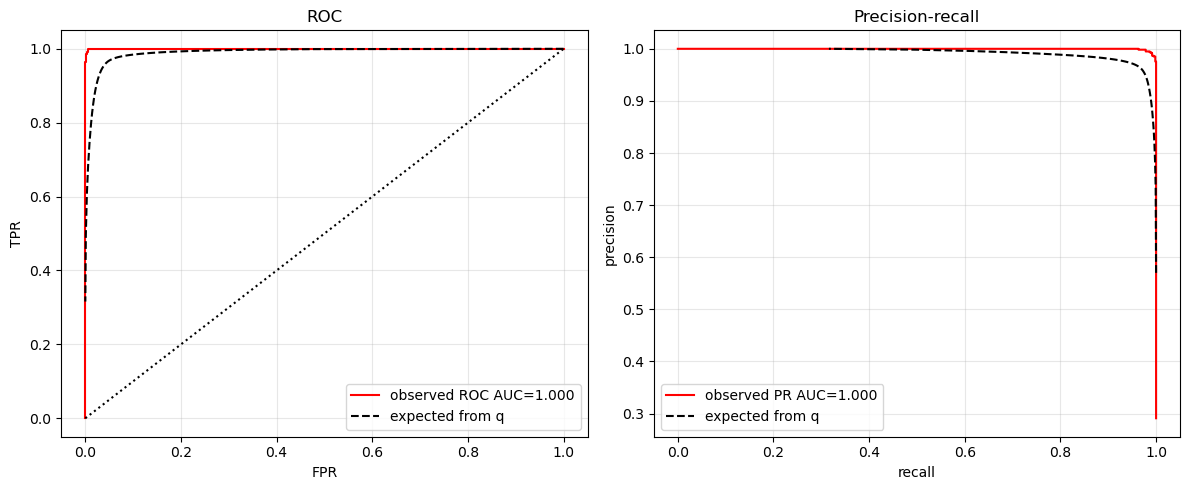


=== Transition-time distribution ===


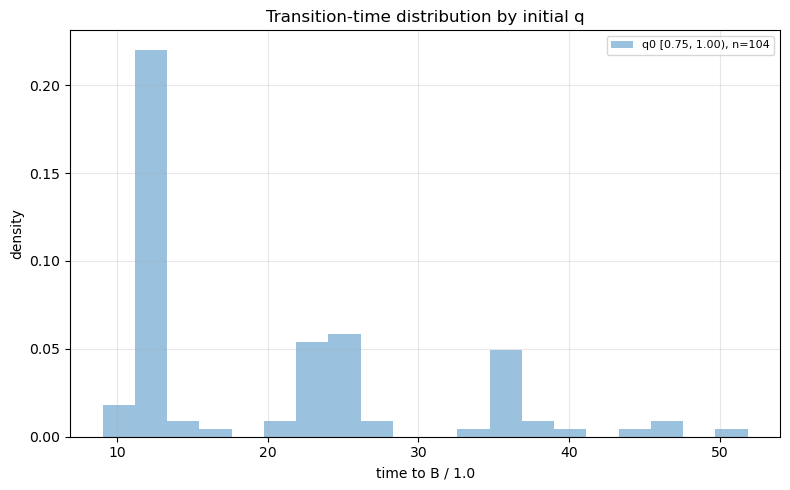


=== Example converter trajectories ===


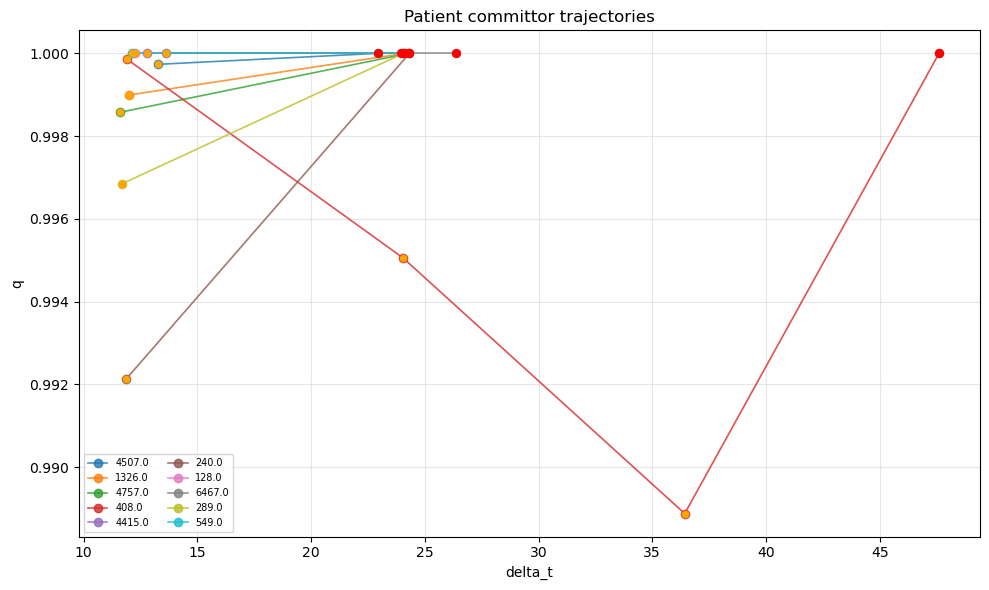


=== Example mid-q trajectories ===


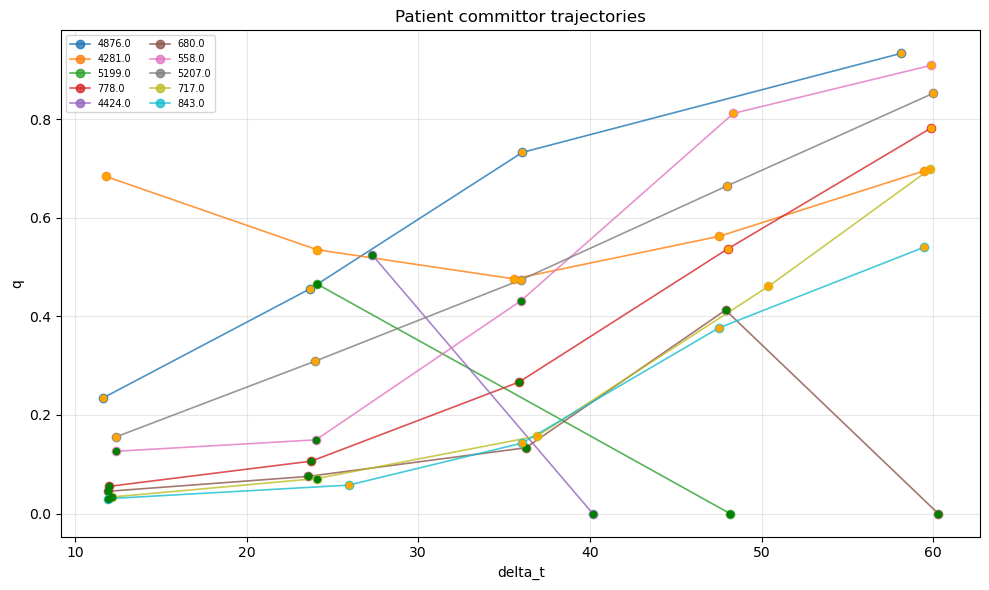


MODEL: optimised_nonlatent

=== Summary ===
n_rows                  3831.000000
n_trajectories          1452.000000
n_boundary0              583.000000
n_boundary1              300.000000
filled_bins               20.000000
interior_bins             18.000000
min_interior_count        33.000000
interior_frac              0.435656
edge_frac                  0.564344
max_abs_zq_deviation       9.874892
max_abs_zq_lag             2.000000
max_sd_zq                  4.495762
max_sd_zq_lag              2.000000
total_zq_variance         32.686043
dtype: float64

=== Standard diagnostics ===
FEP / natural FEP / Zq


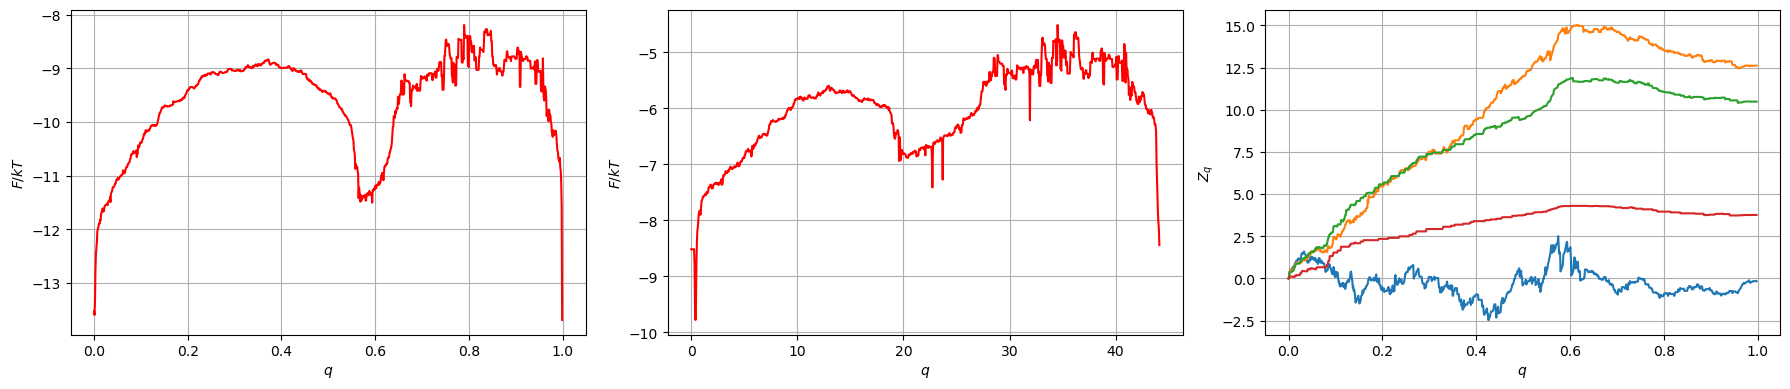

Observed vs predicted


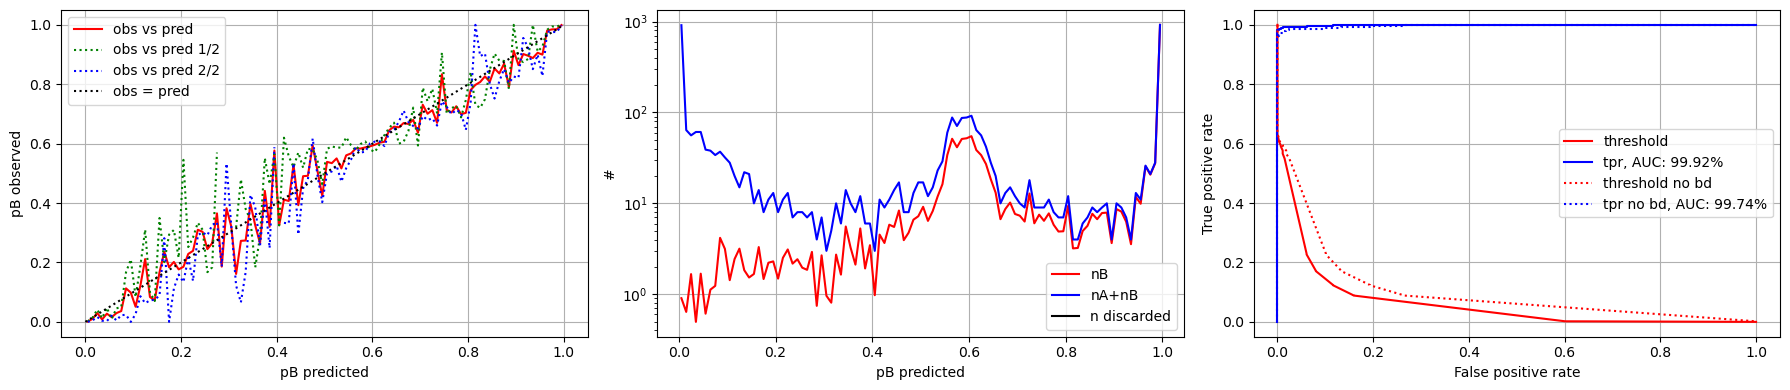

Observed vs predicted, log scale


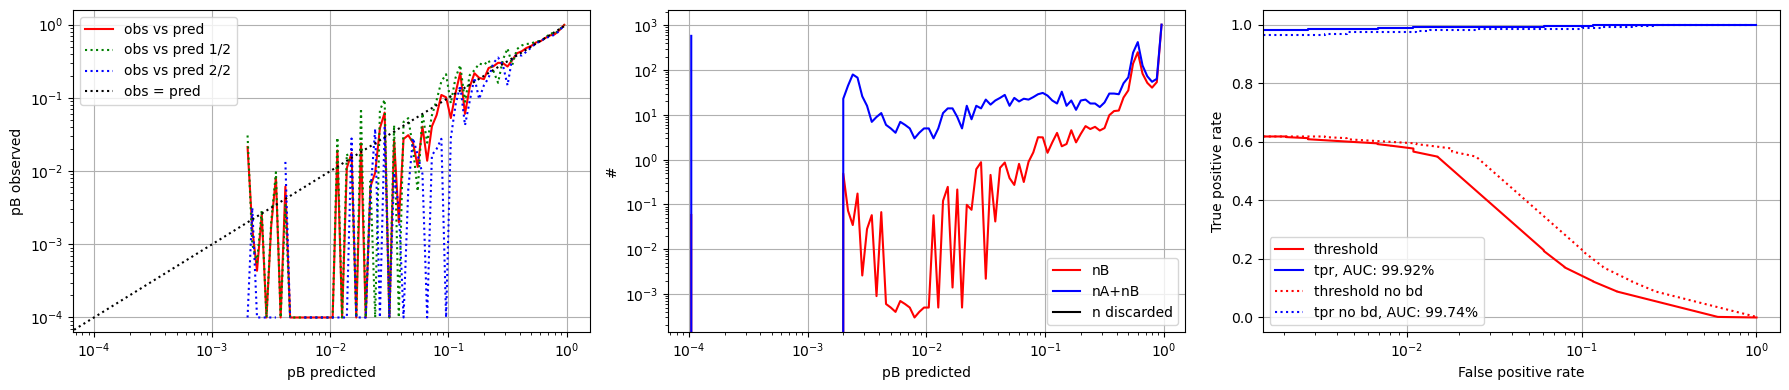


=== Zq only ===


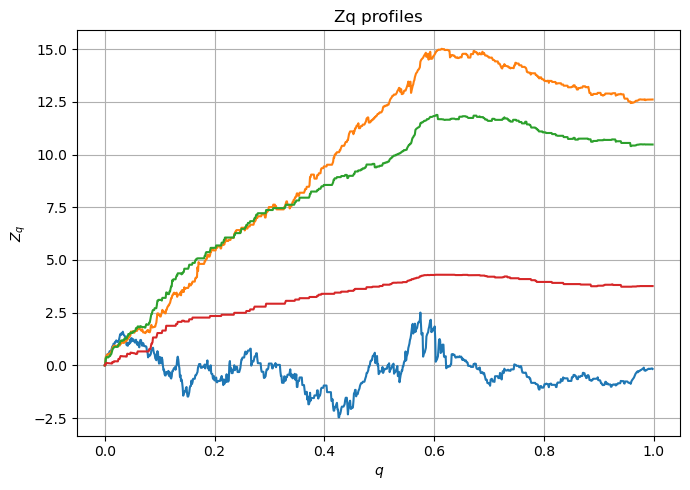


=== q histograms ===


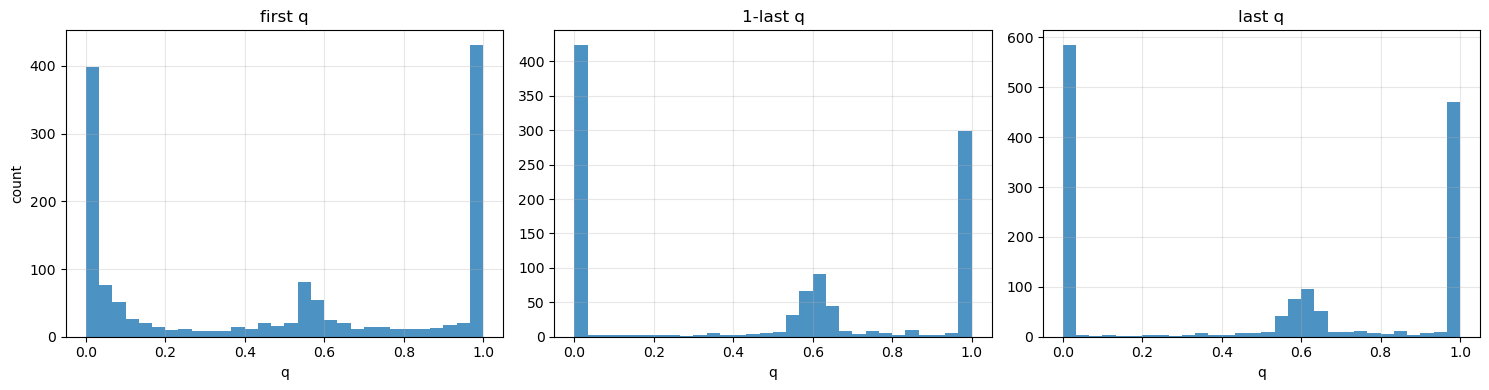


=== First vs kth-last q ===


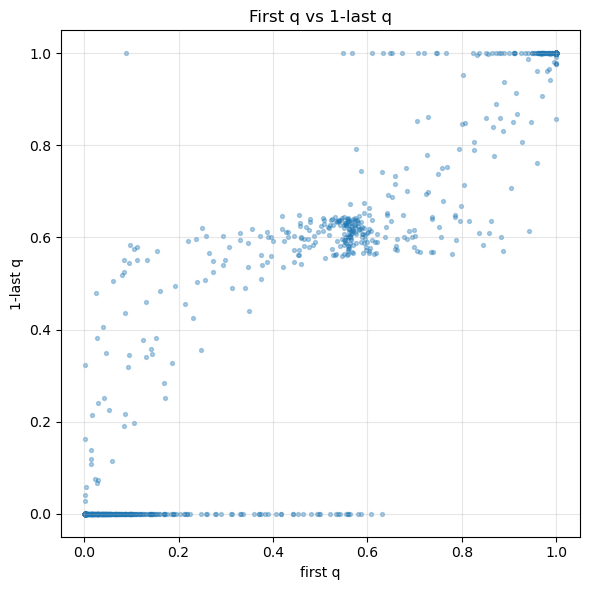

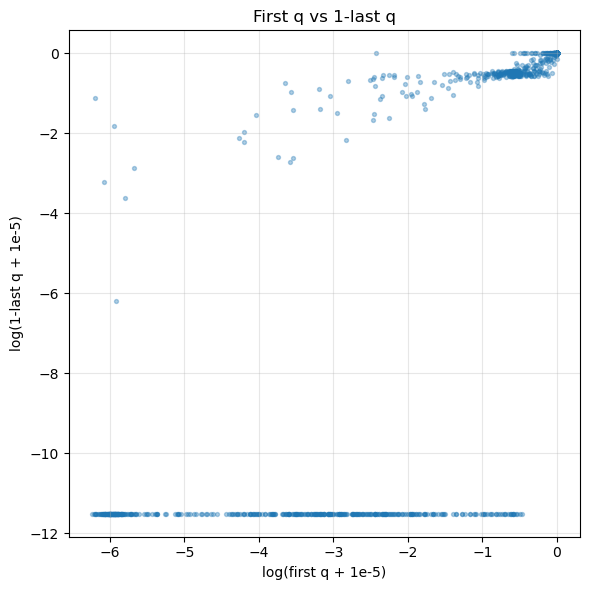


=== kth-last distributions by first-q bin ===


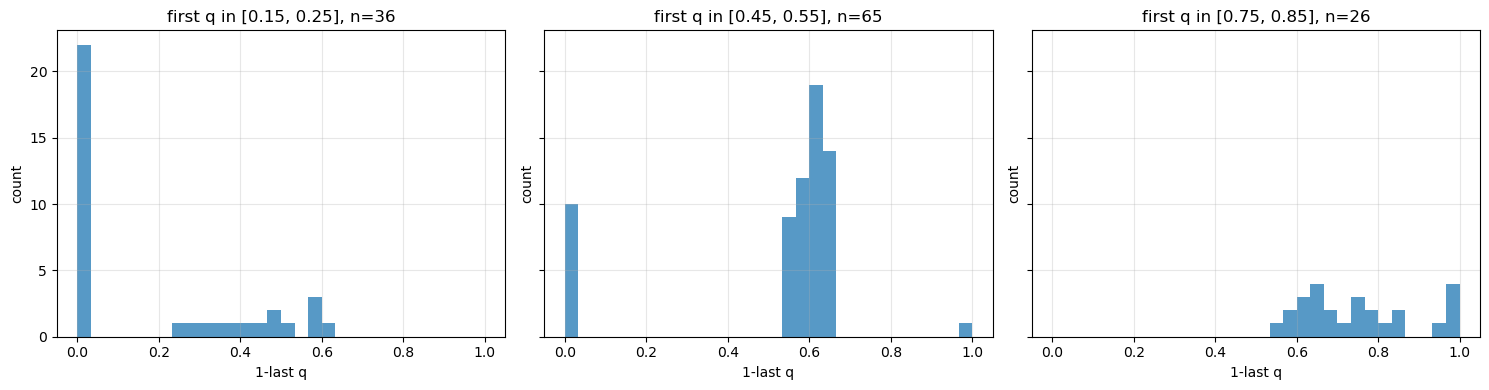


=== ROC / PR ===


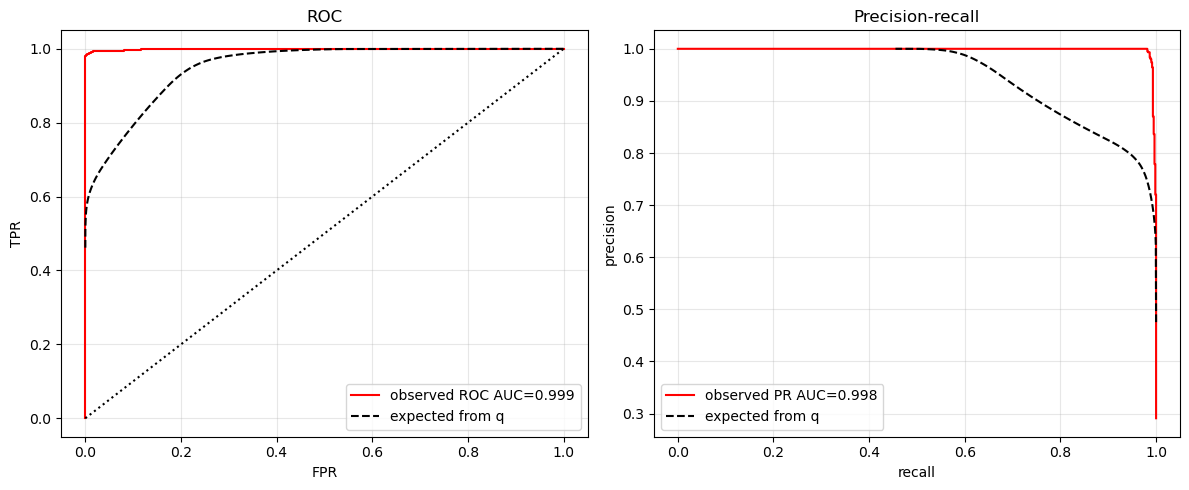


=== Transition-time distribution ===


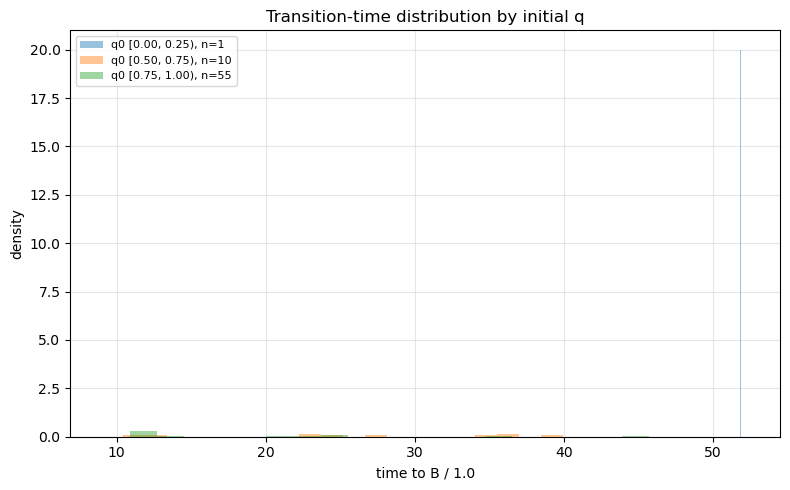


=== Example converter trajectories ===


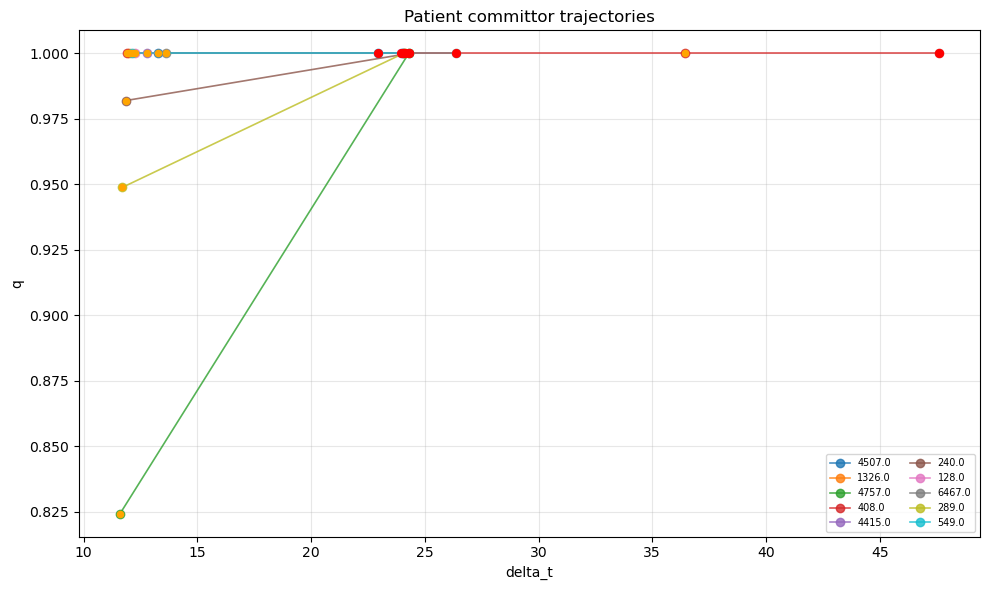


=== Example mid-q trajectories ===


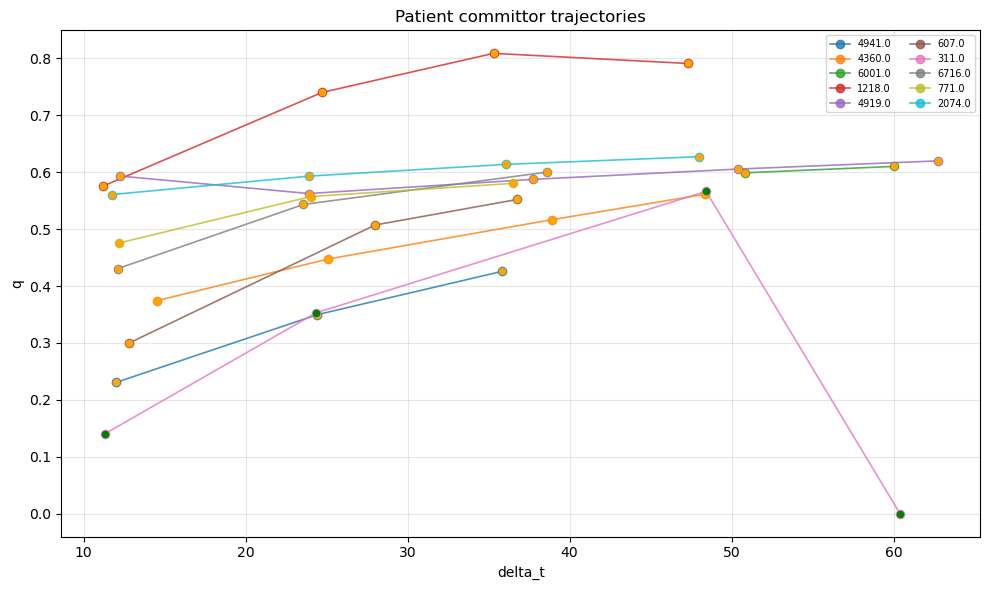


SURVIVAL MODEL COMPARISON
                 model   c_index  monotonicity  event_spread  n_patients  \
0                 base  0.951215           1.0      0.085620        1452   
1     optimised_latent  0.904934           1.0      0.072067        1452   
2  optimised_nonlatent  0.891277           1.0      0.061194        1452   

   n_events  
0       300  
1       300  
2       300  

SURVIVAL PLOTS


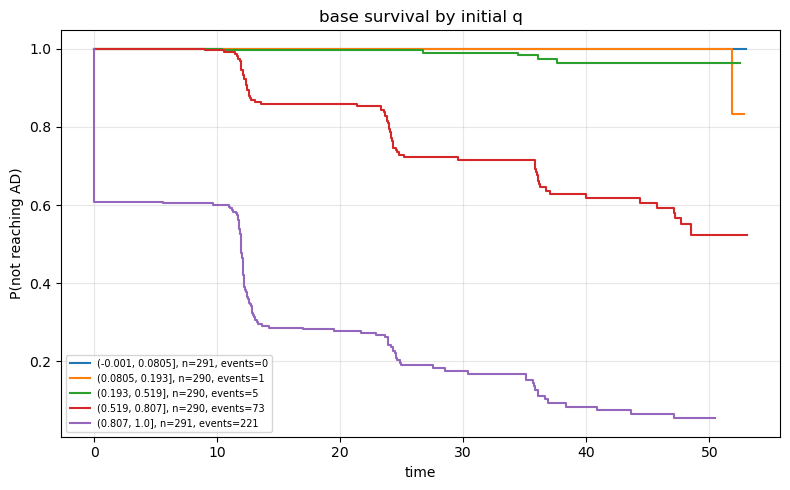

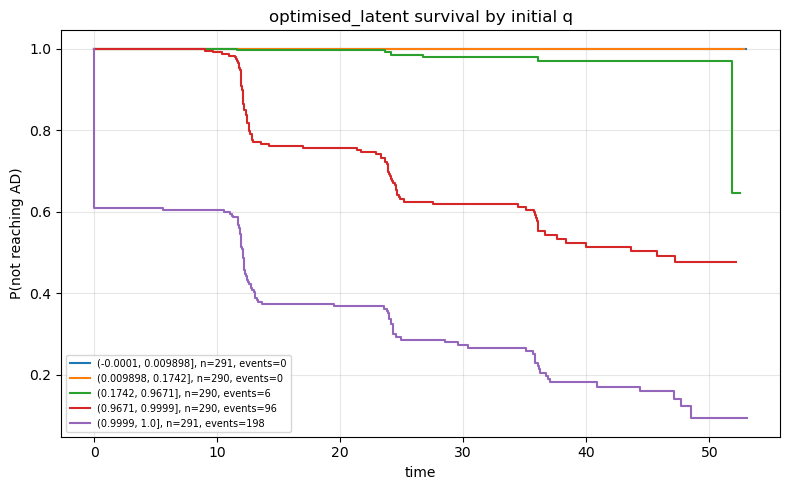

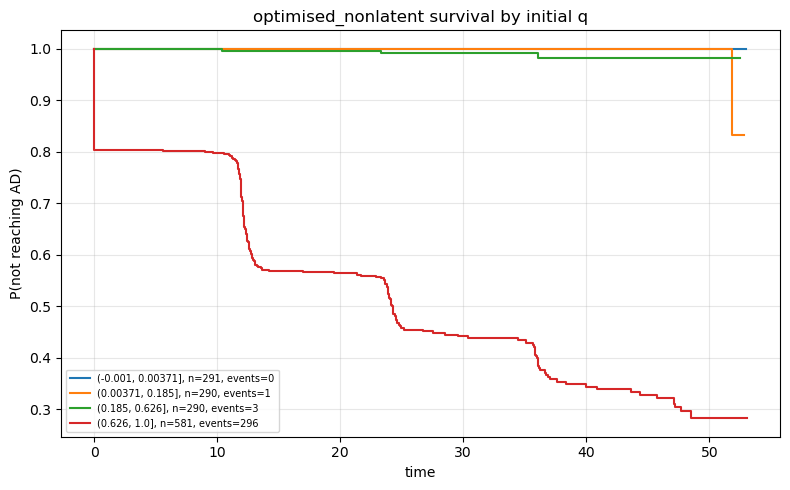

In [215]:
analysis_outputs = run_full_transition_post_analysis_compare(
    q_base=q_transition_base,
    q_latent=q_transition_opt_latent,
    q_nonlatent=q_transition_opt_nonlatent,
    base_summary=transition_base_summary,
    latent_summary=transition_opt_summary_latent,
    nonlatent_summary=transition_opt_summary_nonlatent,
    base_df=transition_base_df,
    latent_df=transition_opt_df_latent,
    nonlatent_df=transition_opt_df_nonlatent,
    lag_times=[1, 2, 3, 4],
    time_scale=1.0,
    n_survival_bins=5,
)

                 model   c_index  monotonicity  event_spread  n_patients  \
0                 base  0.951215          1.00      0.087416        1452   
2  optimised_nonlatent  0.941719          0.75      0.073660        1452   
1     optimised_latent  0.927563          1.00      0.069938        1452   

   n_events  
0       300  
2       300  
1       300  


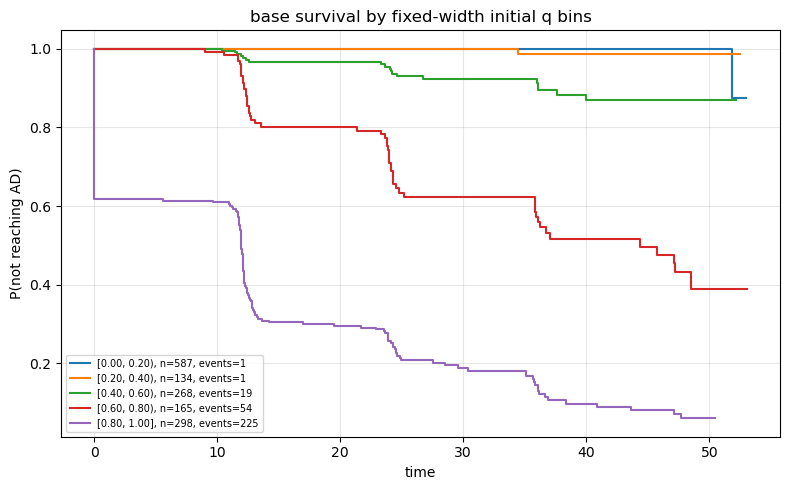

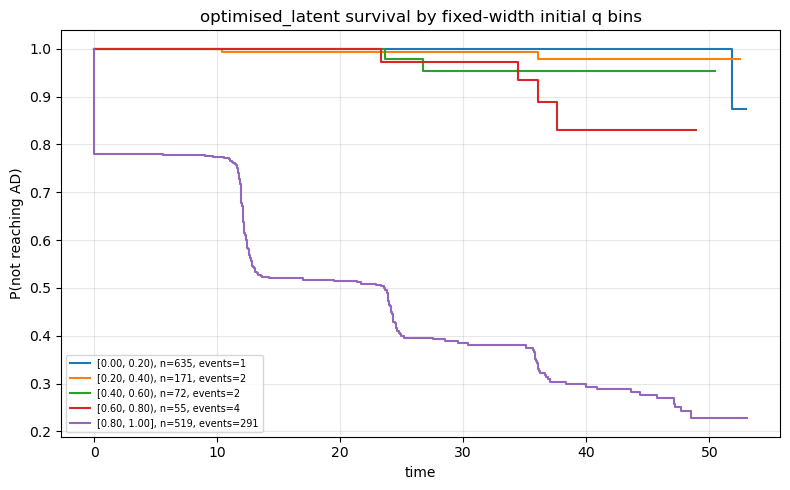

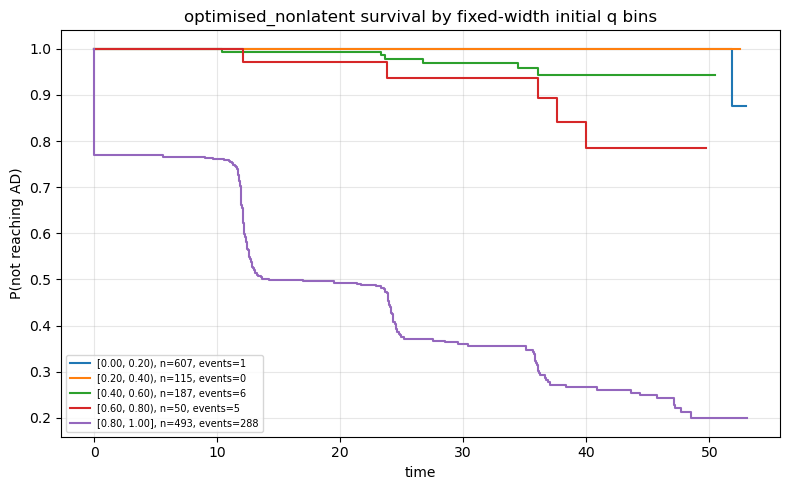

In [220]:
survival_scores_fixed, survival_comparison_fixed = plot_survival_comparison_fixed_bins(
    {
        "base": (q_transition_base, transition_base_df),
        "optimised_latent": (q_transition_opt_latent, transition_opt_df_latent),
        "optimised_nonlatent": (q_transition_opt_nonlatent, transition_opt_df_nonlatent),
    },
    n_bins=5,
    time_scale=1.0,
)


In [225]:
def bootstrap_cindex_difference_fixed_scores(
    survival_scores_fixed,
    model_a="base",
    model_b="optimised_nonlatent",
    n_boot=5000,
    seed=0,
):
    """Paired bootstrap ΔC-index using output from plot_survival_comparison_fixed_bins()."""
    scores_a = survival_scores_fixed[model_a]
    scores_b = survival_scores_fixed[model_b]

    tab_a = scores_a["table"][["RID", "q_first", "time", "event"]].copy()
    tab_b = scores_b["table"][["RID", "q_first", "time", "event"]].copy()

    merged = tab_a.merge(
        tab_b,
        on="RID",
        suffixes=("_a", "_b"),
    )

    rng = np.random.default_rng(seed)
    rids = merged["RID"].to_numpy()
    merged_idx = merged.set_index("RID")

    def cindex(q, time, event):
        concordant = discordant = tied = comparable = 0

        for i in range(len(q)):
            qi, ti, ei = q[i], time[i], event[i]

            for j in range(i + 1, len(q)):
                qj, tj, ej = q[j], time[j], event[j]

                if ei == 1 and ti < tj:
                    comparable += 1
                    if qi > qj:
                        concordant += 1
                    elif qi < qj:
                        discordant += 1
                    else:
                        tied += 1

                elif ej == 1 and tj < ti:
                    comparable += 1
                    if qj > qi:
                        concordant += 1
                    elif qj < qi:
                        discordant += 1
                    else:
                        tied += 1

        return (concordant + 0.5 * tied) / comparable if comparable > 0 else np.nan

    observed_a = scores_a["c_index"]
    observed_b = scores_b["c_index"]
    observed_delta = observed_a - observed_b

    deltas = []

    for _ in range(n_boot):
        sample_rids = rng.choice(rids, size=len(rids), replace=True)
        sample = merged_idx.loc[sample_rids].reset_index()

        ca = cindex(
            sample["q_first_a"].to_numpy(),
            sample["time_a"].to_numpy(),
            sample["event_a"].to_numpy(),
        )

        cb = cindex(
            sample["q_first_b"].to_numpy(),
            sample["time_b"].to_numpy(),
            sample["event_b"].to_numpy(),
        )

        deltas.append(ca - cb)

        print("Bootstrap done: " + str(_))

    deltas = np.asarray(deltas)
    deltas = deltas[np.isfinite(deltas)]

    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])

    p_two_sided = 2 * min(
        np.mean(deltas <= 0),
        np.mean(deltas >= 0),
    )

    result = {
        "comparison": f"{model_a} - {model_b}",
        "observed_cindex_a": float(observed_a),
        "observed_cindex_b": float(observed_b),
        "observed_delta_cindex": float(observed_delta),
        "bootstrap_mean_delta": float(np.mean(deltas)),
        "bootstrap_median_delta": float(np.median(deltas)),
        "ci_95_low": float(ci_low),
        "ci_95_high": float(ci_high),
        "p_two_sided": float(p_two_sided),
        "n_boot": int(len(deltas)),
    }

    print(pd.Series(result))

    plt.figure(figsize=(7, 4))
    plt.hist(deltas, bins=50, alpha=0.75)
    plt.axvline(0, color="k", linestyle="--", label="no difference")
    plt.axvline(ci_low, color="r", linestyle=":", label="95% CI")
    plt.axvline(ci_high, color="r", linestyle=":")
    plt.axvline(observed_delta, color="blue", linestyle="-", label="observed ΔC")
    plt.xlabel(f"Δ C-index ({model_a} - {model_b})")
    plt.ylabel("Bootstrap count")
    plt.title("Paired bootstrap C-index difference")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return result, deltas


Bootstrap done: 0
Bootstrap done: 1
Bootstrap done: 2
Bootstrap done: 3
Bootstrap done: 4
Bootstrap done: 5
Bootstrap done: 6
Bootstrap done: 7
Bootstrap done: 8
Bootstrap done: 9
Bootstrap done: 10
Bootstrap done: 11
Bootstrap done: 12
Bootstrap done: 13
Bootstrap done: 14
Bootstrap done: 15
Bootstrap done: 16
Bootstrap done: 17
Bootstrap done: 18
Bootstrap done: 19
Bootstrap done: 20
Bootstrap done: 21
Bootstrap done: 22
Bootstrap done: 23
Bootstrap done: 24
Bootstrap done: 25
Bootstrap done: 26
Bootstrap done: 27
Bootstrap done: 28
Bootstrap done: 29
Bootstrap done: 30
Bootstrap done: 31
Bootstrap done: 32
Bootstrap done: 33
Bootstrap done: 34
Bootstrap done: 35
Bootstrap done: 36
Bootstrap done: 37
Bootstrap done: 38
Bootstrap done: 39
Bootstrap done: 40
Bootstrap done: 41
Bootstrap done: 42
Bootstrap done: 43
Bootstrap done: 44
Bootstrap done: 45
Bootstrap done: 46
Bootstrap done: 47
Bootstrap done: 48
Bootstrap done: 49
Bootstrap done: 50
Bootstrap done: 51
Bootstrap done: 52
Boo

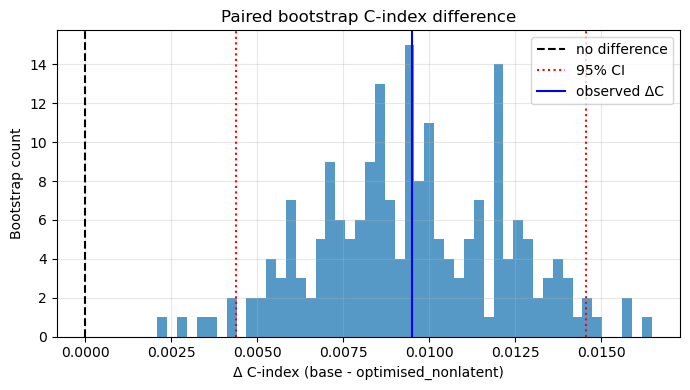

Bootstrap done: 0
Bootstrap done: 1
Bootstrap done: 2
Bootstrap done: 3
Bootstrap done: 4
Bootstrap done: 5
Bootstrap done: 6
Bootstrap done: 7
Bootstrap done: 8
Bootstrap done: 9
Bootstrap done: 10
Bootstrap done: 11
Bootstrap done: 12
Bootstrap done: 13
Bootstrap done: 14
Bootstrap done: 15
Bootstrap done: 16
Bootstrap done: 17
Bootstrap done: 18
Bootstrap done: 19
Bootstrap done: 20
Bootstrap done: 21
Bootstrap done: 22
Bootstrap done: 23
Bootstrap done: 24
Bootstrap done: 25
Bootstrap done: 26
Bootstrap done: 27
Bootstrap done: 28
Bootstrap done: 29
Bootstrap done: 30
Bootstrap done: 31
Bootstrap done: 32
Bootstrap done: 33
Bootstrap done: 34
Bootstrap done: 35
Bootstrap done: 36
Bootstrap done: 37
Bootstrap done: 38
Bootstrap done: 39
Bootstrap done: 40
Bootstrap done: 41
Bootstrap done: 42
Bootstrap done: 43
Bootstrap done: 44
Bootstrap done: 45
Bootstrap done: 46
Bootstrap done: 47
Bootstrap done: 48
Bootstrap done: 49
Bootstrap done: 50
Bootstrap done: 51
Bootstrap done: 52
Boo

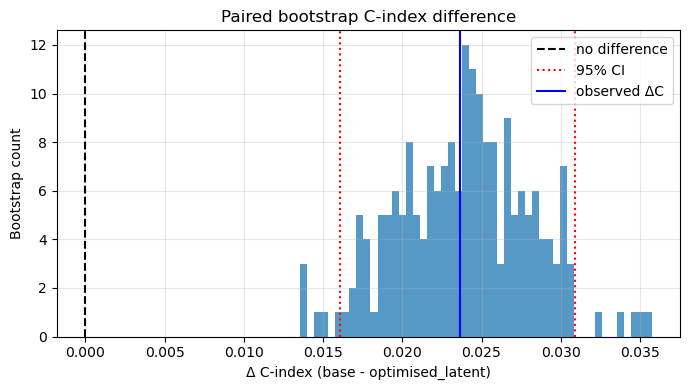

In [228]:
boot_base_vs_nonlatent, deltas_base_vs_nonlatent = bootstrap_cindex_difference_fixed_scores(
    survival_scores_fixed,
    model_a="base",
    model_b="optimised_nonlatent",
    n_boot=200,
    seed=0,
)

boot_base_vs_latent, deltas_base_vs_latent = bootstrap_cindex_difference_fixed_scores(
    survival_scores_fixed,
    model_a="base",
    model_b="optimised_latent",
    n_boot=200,
    seed=0,
)